# Google Data Analytics Capstone Project - Cyclistic 2024 

## Table of Contents

1. [Introduction](#Introduction)
2. [Ask](#1.-Ask)
3. [Prepare](#2.-Prepare)
4. [Process](#3.-Process)
   - [3.1 Documenting data cleaning process and manipulation](#3.1-Documenting-data-cleaning-process-and-manipulation)
   - [3.2 Dataset Imported to Kaggle and R summary of data](#3.2-Dataset-Imported-to-Kaggle-and-R-summary-of-data)
   - [3.3 Preparing my environment](#3.3-Preparing-my-environment)
5. [Analysis](#4.-Analysis)
   - [4.1 Analysing Ride Volume](#4.1-Analysing-Ride-Volume)
   - [4.2 Analysing Ride Duration](#4.2-Analysing-Ride-Duration)
   - [4.3 Analysing Type of Rides](#4.3-Analysing-Type-of-Rides)
6. [Share](#5.-Share)
7. [Act](#6.-Act)
8. [Conclusion](#7.-Conclusion)

## Introduction
This report presents an analysis of Cyclist ride data from 2024, prepared for the Marketing Department to support future business decisions. The goal is to uncover members behaviours and patterns through 2024 and its’ influence to the company. The analysis is conducted as part of the Google Data Analytics Professional Certificate capstone, using a hypothetical company ("Cyclist") and real-world ride data from Divvy Bikes a bike-sharing service based in Chicago.

## 1. Ask
#### What is the problem trying to be solved? 
The problem trying to be solved is to increase conversion from casual members to annual members.
#### How can insights be used to drive business decisions?
By understanding behaviours and trends from both members (casual and annual), it is expected to identify and correlate patterns that will guide targeting casual members that could benefit more from the annual membership and how this could be done.
#### Identify the business task
Identifying trends and key information that helps distinguish casual riders from annual members to help the marketing team understand how to set a strategy visioning converting casual members to annual members.
#### Key stakeholders
Lily Moreno: The director of marketing and “my” manager.
Cyclistic marketing analytics team: A team of data analysts who are responsible for collecting, analysing, and reporting data that helps guide Cyclistic's marketing strategy.
Cyclistic executive team: The notoriously detail-oriented executive team will decide whether to approve the recommended marketing program.
Cyclistic users: 
•	Casual members: Customers who purchase single-ride or full-day passes
•	Annual members: Customers who purchase annual memberships


## 2. Prepare
#### Data Preparation and Overview
Data was downloaded from the [Index of bucket "divvy-tripdata"](https://divvy-tripdata.s3.amazonaws.com/index.html) where 2024 data has been downloaded from January to December.
All datasets contain the following columns:
1. ride_id: Unique identifier for each ride
2. rideable_type: Type of bike used for the ride
3. started_at: Start time of the ride
4. ended_at: End time of the ride
5. start_station_name: Name of the station where the ride started
6. end_station_name: Name of the station where the ride ended
7. start_station_id: Unique identifier for the start station
8. end_station_id: Unique identifier for the end station
9. start_lat: Latitude of the start station
10. start_lng: Longitude of the start station
11. end_lat: Latitude of the end station
12. end_lng: Longitude of the end station
13. member_casual: Type of membership (member or casual)

Data was downloaded by month (Jan 24 to Dec 24) - 12 csv files were stored appropriately on the local desktop.
The files were uploaded to the GCS (Google Cloud Storage) and merged automatically with BigQuery while linking the 2024 bucket when creating a table on BigQuery ‘cyclistic_24’.
#### Credibility of the data.
The data is credible and reliable as it comes directly from the official [Divvy Trip Data](https://divvy-tripdata.s3.amazonaws.com/index.html) website, managed by Motivate International Inc.
The data is ROCCC because it is Reliable, Original, Comprehensive, Current, and Cited. It represents real user trips collected, covering all of 2024 to ensure an updated, complete year of insights. 
#### License
The data has been made available by Motivate International Inc. under this [license](https://divvybikes.com/data-license-agreement). This is public data that can be used to explore how different customer types are using Cyclistic bikes.
#### Problems with the Data
There are minor limitations, such as the absence of personal or demographic data and the focus solely on the Chicago area, which may slightly limit broader generalisation.
The dataset does not include membership pricing or cost information, which caps revenue calculation and profitability assessment, or determining which membership option offers more value to users based on their spending.
Each ride_id does not represent the user and channel of purchase. All observations are intended for educational purposes, not real-life business recommendations.


## 3. Process
### 3.1 Documenting data cleaning process and manipulation
The process of cleaning was done with SQL using BigQuery, the data cleaning process can be seen on the following [file](https://github.com/johngod194/Google-Data-Analytics---Capstone-Project-1/blob/main/SQL%20Cleaning) on github


#### Clean version and transformation completed
The clean version was created and named as 'cyclistic_24_cleaned'.
There were several columns added in relation to the data from [Index of bucket "divvy-tripdata"](https://divvy-tripdata.s3.amazonaws.com/index.html) such as:
* ride_lenght
* day
* month
* weekday

Having now 9 columns as per below:
1. ride_id: Unique identifier for each ride
2. rideable_type: Type of bike used for the ride
3. started_at: Start time of the ride
4. ended_at: End time of the ride
5. ride_length - Duration of the ride
6. day - Day of the month the ride occured
7. month - Month the ride occured
8. weekday - name of the Day of the week the ride occured
9. member_casual: Type of membership (member or casual)

The dataset was fully cleaned no NULLs, no duplicates, and no rides_length with less than 1 min could be found, ending with a total of 4168627 lines. 

### 3.2 Dataset Imported to Kaggle and R summary of data
Final version has been downloaded as csv file and the dataset was uploaded to kaggle as 'cyclistic_24'.

### 3.3 Preparing my environment
The Analysis part will be done using R, therefore, the environment will need to be set by loading the needed packages, importing the cyclistic_24 dataset and finally checking the information about the dataset imported.

In [1]:
# 1. Setting up my Environment
# Notes: setting up my R environment by loading the tidyverse, skimr, janitor, scales, patchwork, lubridate, stringr, forcats and hms packages.
library(tidyverse)  
library(skimr)
library(janitor)
library(scales)
library(patchwork)
library(lubridate)
library(stringr)
library(forcats)
library(hms)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test





Attaching package: ‘scales’




The following object is masked from ‘package:purrr’:

    discard




The following object is masked from ‘package:readr’:

    col_factor





Attaching package: ‘hms’




The following object is masked from ‘package:lubridate’:

    hms




In [2]:
# 2. Importing my dataset
file_path <- "//kaggle/input/cyclistic-24-cleanedv2/cyclistic_24_cleanedV2.csv"
cyclistic_24 <- read.csv(file_path)


In [3]:
# 3. Information about the dataset
colnames(cyclistic_24)
glimpse(cyclistic_24)
summary(cyclistic_24)

[1] "ride_id"       "started_at"    "ended_at"      "ride_length"  
[5] "day"           "month"         "weekday"       "rideable_type"
[9] "member_casual"

Rows: 4,168,627
Columns: 9
$ ride_id       <chr> "79C40E1E65E476D9", "4C9B4B6F9E226983", "48FE138D9F08E68…
$ started_at    <chr> "16:10:36", "13:10:55", "15:45:25", "11:18:01", "17:23:1…
$ ended_at      <chr> "16:12:34", "13:12:32", "15:47:21", "11:19:14", "17:24:5…
$ ride_length   <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ day           <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ month         <int> 10, 5, 8, 9, 2, 2, 7, 2, 10, 7, 8, 11, 5, 11, 4, 1, 9, 1…
$ weekday       <chr> "Tuesday", "Wednesday", "Thursday", "Sunday", "Thursday"…
$ rideable_type <chr> "electric_bike", "electric_bike", "classic_bike", "class…
$ member_casual <chr> "member", "member", "member", "member", "member", "membe…


   ride_id           started_at          ended_at          ride_length     
 Length:4168627     Length:4168627     Length:4168627     Min.   :   1.00  
 Class :character   Class :character   Class :character   1st Qu.:   5.00  
 Mode  :character   Mode  :character   Mode  :character   Median :  10.00  
                                                          Mean   :  16.32  
                                                          3rd Qu.:  18.00  
                                                          Max.   :1509.00  
      day            month          weekday          rideable_type     
 Min.   : 1.00   Min.   : 1.000   Length:4168627     Length:4168627    
 1st Qu.: 8.00   1st Qu.: 5.000   Class :character   Class :character  
 Median :15.00   Median : 7.000   Mode  :character   Mode  :character  
 Mean   :15.62   Mean   : 6.965                                        
 3rd Qu.:23.00   3rd Qu.: 9.000                                        
 Max.   :31.00   Max.   :12.000     

Found the started_at and ended_at were in character format so this was change as per below

In [4]:
#formating started_at and ended_at 
cyclistic_24 <- cyclistic_24 %>%
  mutate(
    started_at = hms::as_hms(started_at),
    ended_at   = hms::as_hms(ended_at),
    start_hour = hour(started_at),
    end_hour   = hour(ended_at)
  )


In [5]:
mean(cyclistic_24$ride_length, na.rm = TRUE)

aggregate(
  ride_length ~ member_casual,
  data = cyclistic_24,
  FUN = mean,
  na.rm = TRUE
)

[1] 16.31823

member_casual,ride_length
<chr>,<dbl>
casual,23.79280
member,12.08928


## 4. Analysis

### Executive Summary
In this stage, we are looking to compare and understand how casual members and annual members use Cyclistic, considering different types of timeframes, the length of rides and the type of ride being used. It is expected that by understanding these patterns, we will be able to make better recommendations on how to convert casual members into annual members.

**Note:** According to the Cyclistic team, Cyclistic users are more likely to ride for leisure, but about 30% use the bikes to commute to work each day.

### 4.1 Analysing Ride Volume

# A tibble: 2 × 2
  member_casual total_rides
  <chr>               <int>
1 casual            1506292
2 member            2662335


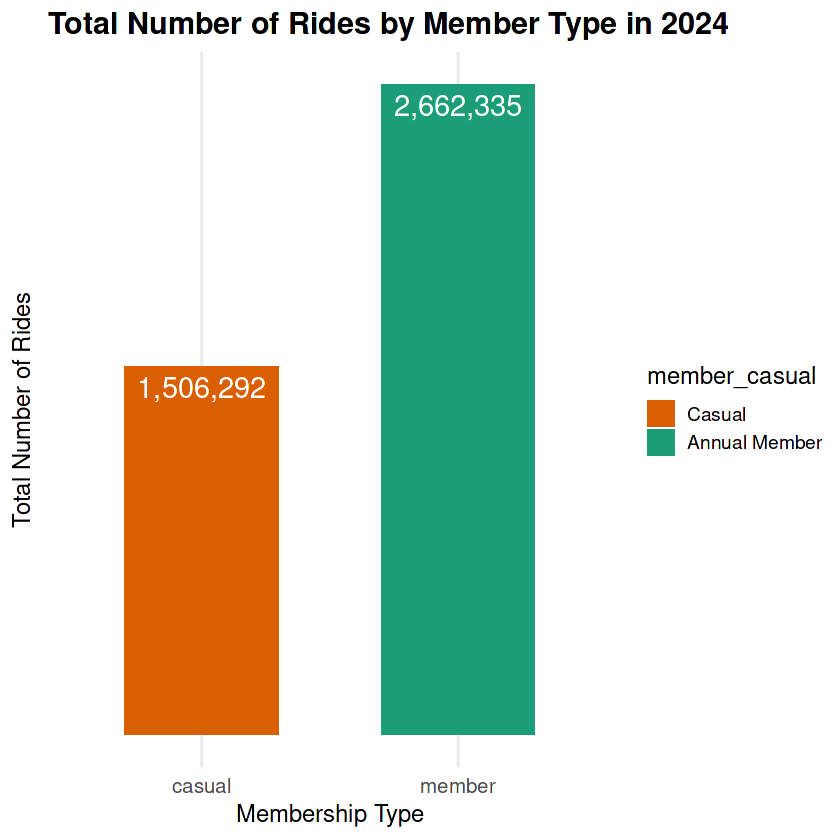

In [6]:
# Total number of rides between casual and annual member
total_rides <- cyclistic_24 %>%
  group_by(member_casual) %>%
  summarise(total_rides = n())

print(total_rides)

# Plot
ggplot(total_rides, aes(x = member_casual, y = total_rides, fill = member_casual)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(
      aes(label = label_comma()(total_rides)),  # nicely formatted numbers
    colour = "white",
    size = 6,        
    vjust = 1.5      
  ) +
  labs(
    title = "Total Number of Rides by Member Type in 2024",
    x = "Membership Type",
    y = "Total Number of Rides"
  ) +
  theme_minimal() +
  scale_fill_manual(values = c("casual" = "#d95f02", "member" = "#1b9e77"),
                    labels = c("Casual", "Annual Member"))+
theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
      axis.text.x = element_text(size = 12),
      axis.text.y  = element_blank(),
    axis.ticks.y = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank()
  )


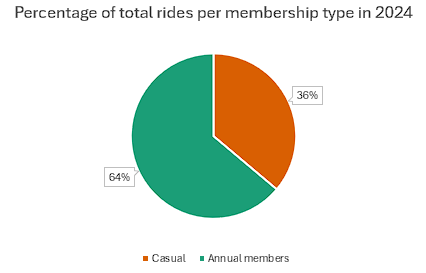

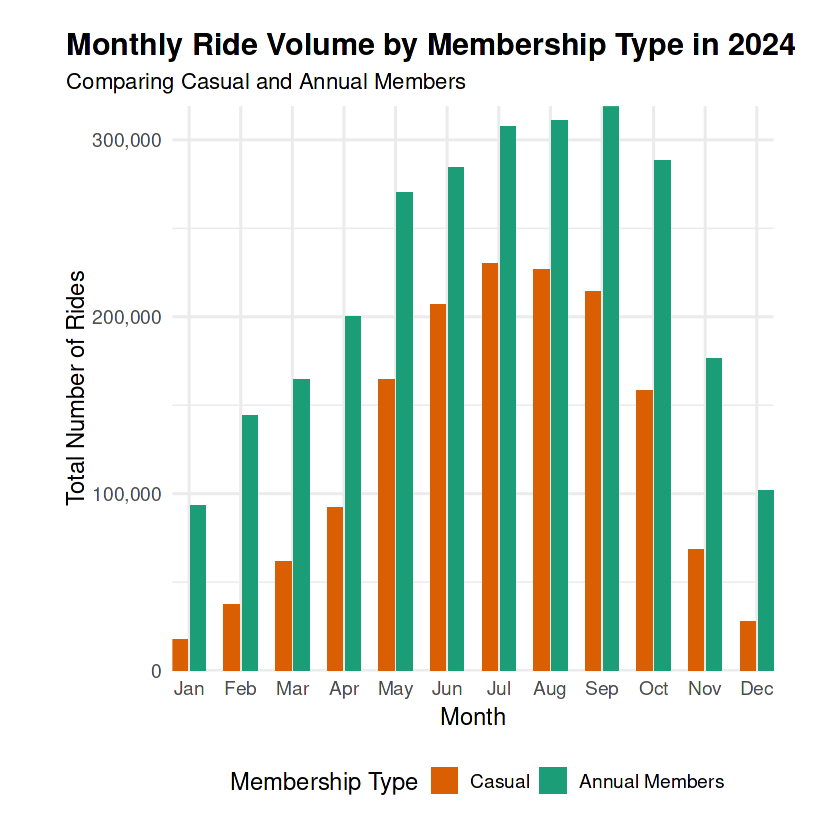

In [7]:
monthly_rides <- cyclistic_24 %>%
  group_by(month, member_casual) %>%
  summarise(total_rides = n(), .groups = "drop") %>%
  mutate(
    month = factor(month, levels = 1:12, labels = month.abb, ordered = TRUE)
  )

#plot
ggplot(monthly_rides, aes(x = month, y = total_rides, fill = member_casual)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +

  labs(
    title = "Monthly Ride Volume by Membership Type in 2024",
    subtitle = "Comparing Casual and Annual Members",
    x = "Month",
    y = "Total Number of Rides",
    fill = "Membership Type"
  ) +

  scale_fill_manual(
    values = c("casual" = "#d95f02", "member" = "#1b9e77"),
    labels = c("Casual", "Annual Members")
  ) +

  scale_y_continuous(labels = label_comma()) +

  theme_minimal(base_size = 14) +
  theme(
       plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",
    plot.margin = margin(20, 40, 20, 40)  # top, right, bottom, left margins larger
  ) +

  coord_cartesian(expand = FALSE)  # Avoid default padding, making bars span wider


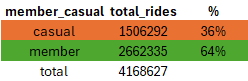


The last two plots reflect that the Annual members had a higher number of rides throughout the year, representing 64% of the total rides. Also, when we look to how the volume is spreaded monthly we can see the peak of riding is between June and October, which could correlate with Summer season and the number of rides seem to decrease more from the casual riders than from the annual members, for instance in November the casual riders had a decrease of 57% in relation to the previous month while the annual members had a deecrease of 39%. 

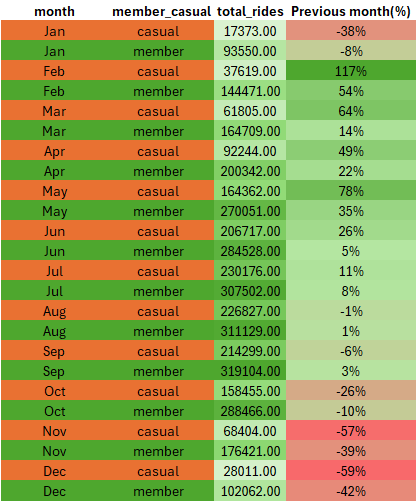



The level of decrease mentioned above between casual and annual members is pointed out in the table above, where we can see the highest declines happening in November, followed by December. And the casual members  have a larger decrease than the annual members, suggesting the volume of rides on the annual members is more stable throughout the year.

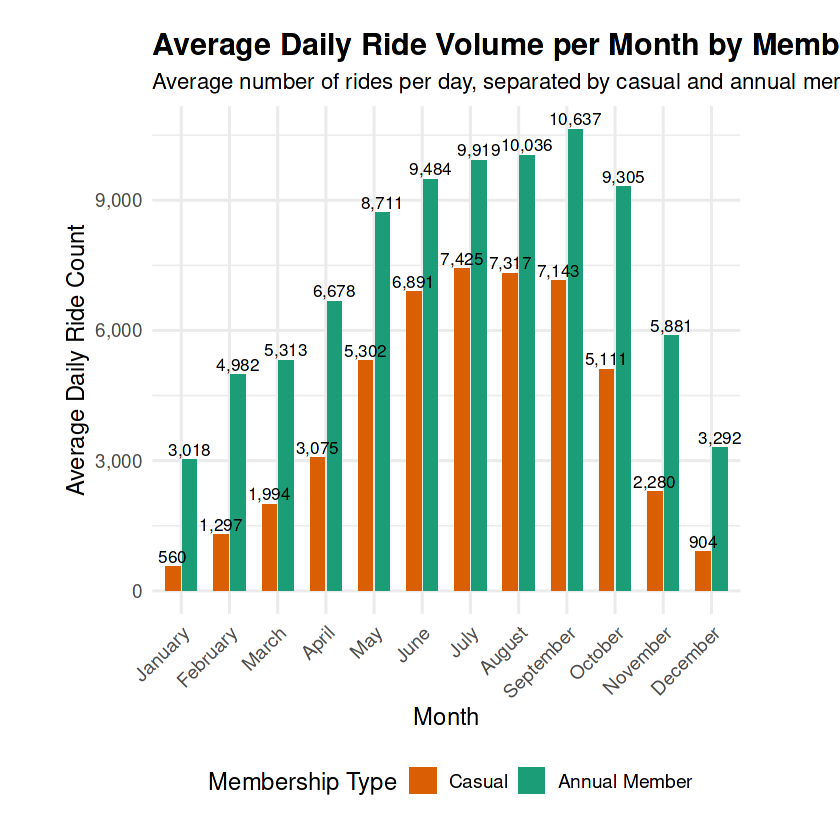

In [8]:
# Calculate average rides per month per membership type 
avg_monthly_rides_member <- cyclistic_24 %>%
  group_by(month, member_casual) %>%
  summarise(avg_rides = n() / n_distinct(day), .groups = "drop") %>%
  mutate(
    month = factor(month, levels = 1:12, labels = month.name, ordered = TRUE)
  )

#  Plot: Average Monthly Ride Volume per Membership Type 
ggplot(avg_monthly_rides_member, aes(x = month, y = avg_rides, fill = member_casual)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +  # Side-by-side bars
  geom_text(
    aes(label = scales::comma(round(avg_rides, 0))),
    position = position_dodge(width = 0.7),
    vjust = -0.3,
    size = 3.5,
    color = "black"
  ) +
  labs(
    title = "Average Daily Ride Volume per Month by Membership Type (2024)",
    subtitle = "Average number of rides per day, separated by casual and annual members",
    x = "Month",
    y = "Average Daily Ride Count",
    fill = "Membership Type"
  ) +
  scale_fill_manual(
    values = c("casual" = "#d95f02", "member" = "#1b9e77"),
    labels = c("Casual", "Annual Member")
  ) +
  scale_y_continuous(labels = scales::label_comma()) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.text.y = element_text(size = 11),
    plot.margin = margin(20, 60, 20, 40)
  )


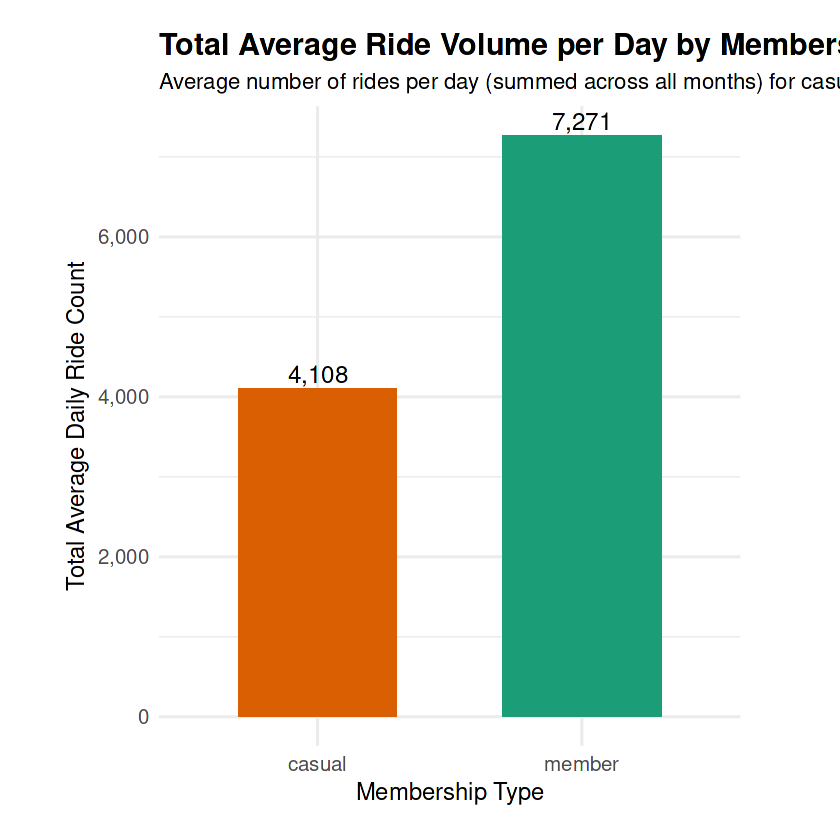

In [9]:
# Calculate total rides per membership type, grouped by month and day 
avg_rides_per_day_by_month_member <- cyclistic_24 %>%
  group_by(month, day, member_casual) %>%  # Group by month and day to correctly calculate the average
  summarise(total_rides = n(), .groups = "drop") %>%  # Count the rides per day
  group_by(month, member_casual) %>%  # Now group by month and membership type for final average calculation
  summarise(
    total_rides = sum(total_rides),  # Sum the total rides for each month and membership type
    total_days = n_distinct(day),    # Count distinct days per month
    avg_rides_per_day = total_rides / total_days,  # Calculate the average rides per day
    .groups = "drop"
  ) %>%
  mutate(month = factor(month, levels = 1:12, labels = month.name, ordered = TRUE))  # Convert month to a factor for plotting

# Calculate the total average rides per day across all months for each membership type 
avg_total_rides_per_day <- avg_rides_per_day_by_month_member %>%
  group_by(member_casual) %>%
  summarise(
    total_avg_rides_per_day = mean(avg_rides_per_day),  # Average the daily averages across the 12 months
    .groups = "drop"
  )

# Plot: Total Average Ride Volume per Day by Membership Type 
ggplot(avg_total_rides_per_day, aes(x = member_casual, y = total_avg_rides_per_day, fill = member_casual)) +
  geom_col(width = 0.6) +  # Bar chart for total average rides per day by membership type
  geom_text(
    aes(label = scales::comma(round(total_avg_rides_per_day, 0))),
    vjust = -0.3,  # Place the label above the bar
    size = 5,
    color = "black"
  ) +
  labs(
    title = "Total Average Ride Volume per Day by Membership Type in 2024",
    subtitle = "Average number of rides per day (summed across all months) for casual and annual members",
    x = "Membership Type",
    y = "Total Average Daily Ride Count",
    fill = "Membership Type"
  ) +
  scale_fill_manual(values = c("casual" = "#d95f02", "member" = "#1b9e77")) +  # Custom colors for membership types
  scale_y_continuous(labels = scales::label_comma()) +  # Format the y-axis with commas
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "none",  # No legend needed, as membership types are labeled directly
    axis.text.x = element_text(size = 12),
    axis.text.y = element_text(size = 12),
    plot.margin = margin(20, 60, 20, 40)
  )


# A tibble: 14 × 3
   weekday   member_casual total_rides
   <chr>     <chr>               <int>
 1 Friday    casual             220299
 2 Friday    member             373257
 3 Monday    casual             179852
 4 Monday    member             395734
 5 Saturday  casual             314495
 6 Saturday  member             329385
 7 Sunday    casual             263404
 8 Sunday    member             292813
 9 Thursday  casual             181320
10 Thursday  member             410595
11 Tuesday   casual             161306
12 Tuesday   member             417788
13 Wednesday casual             185616
14 Wednesday member             442763


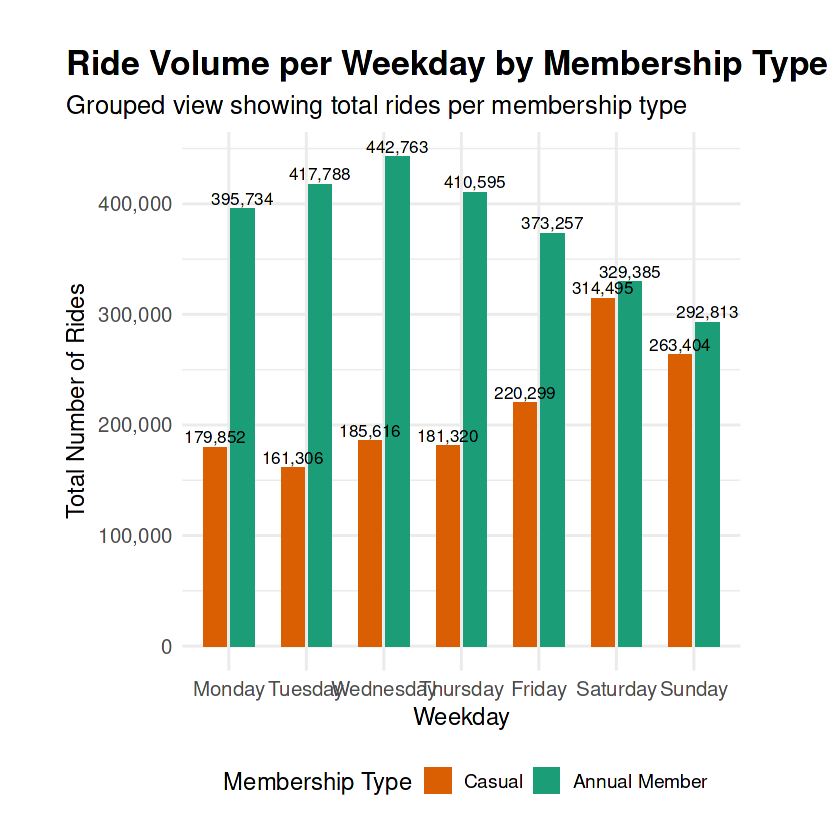

In [10]:
weekday_rides <- cyclistic_24 %>%
  group_by(weekday, member_casual) %>%
  summarise(total_rides = n(), .groups = "drop") 

print(weekday_rides)

weekday_rides$weekday <- factor(
  weekday_rides$weekday,
  levels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"),
  ordered = TRUE
)

# Grouped Column Chart: Ride Volume per Weekday by Membership Type 
ggplot(weekday_rides, aes(x = weekday, y = total_rides, fill = member_casual)) +
  geom_col(width = 0.6, position = position_dodge(width = 0.7)) +  
  geom_text(
    aes(label = scales::comma(total_rides)),
    position = position_dodge(width = 0.7),
    vjust = -0.3,          # Slightly above the bar
    size = 3.5, 
    color = "black"
  ) +
  labs(
    title = "Ride Volume per Weekday by Membership Type in 2024",
    subtitle = "Grouped view showing total rides per membership type",
    x = "Weekday",
    y = "Total Number of Rides",
    fill = "Membership Type"
  ) +
  scale_fill_manual(
    values = c("casual" = "#d95f02", "member" = "#1b9e77"),
    labels = c("Casual", "Annual Member")
  ) +
  scale_y_continuous(labels = scales::label_comma()) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 20),  # Increase title size
    plot.subtitle = element_text(size = 15),  # Increase subtitle size
    legend.position = "bottom",
    plot.margin = margin(30, 60, 20, 40),  # Increase margin for better spacing
    axis.text.x = element_text(size = 12),
    axis.text.y = element_text(size = 12)
  ) +
  coord_cartesian(expand = TRUE)

# Save the plot with larger dimensions for better readability
ggsave("weekday_ride_volume.png", width = 12, height = 8, dpi = 300, limitsize = FALSE)


In terms of rides per weekday, although the annual members have a higher volume of rides than the casual members during the working days, the rides of casual members during the weekend seem to increase considerably. This can suggest that the annual members may use Cyclistic as a way to commute to their jobs, schools/universities, etc... while the casual riders may use it whenever convenient, or in their spare time. At the same time, this makes us reflect on whether the casual members ride as a hobby or for convenience, and why they would not opt for the annual membership plan? We hope to dismantle that during further analysis.

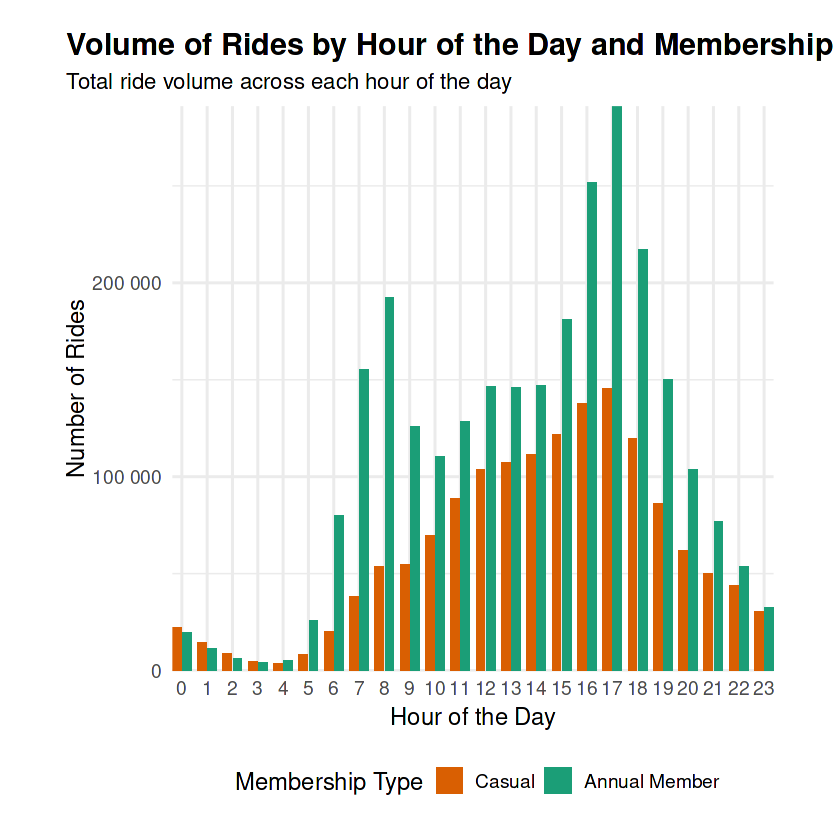

In [11]:
# Ride Count by Hour of the Day 

# Create dataset with hour-based categorization
cyclistic_hourly <- cyclistic_24 %>%
  mutate(
    hour = hour(started_at)  # Extract hour from the timestamp
  )

# Compute ride count per hour and member type
hourly_count <- cyclistic_hourly %>%
  group_by(hour, member_casual) %>%
  summarise(ride_count = n(), .groups = "drop")  # Count rides per hour

# Plot: Ride Count by Hour of the Day
ggplot(hourly_count, aes(x = factor(hour), y = ride_count, fill = member_casual)) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +

  labs(
    title = "Volume of Rides by Hour of the Day and Membership Type in 2024",
    subtitle = "Total ride volume across each hour of the day",
    x = "Hour of the Day",
    y = "Number of Rides",
    fill = "Membership Type"
  ) +

  scale_fill_manual(
    values = c("casual" = "#d95f02", "member" = "#1b9e77"),
    labels = c("Casual", "Annual Member")
  ) +

  scale_y_continuous(
    labels = label_number(accuracy = 1),
    expand = expansion(mult = c(0, 0.05))
  ) +

  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",
    plot.margin = margin(20, 40, 20, 40)
  ) +

  coord_cartesian(expand = FALSE)


Considering the volume of rides per hour, we can observe that the annual members volumes are higher than the casual members and that two periods stand: in the morning from 7am to 9am and in the afternoon from 4pm to 6pm. This could reflect periods during the working days where a considerable number of people are commuting to their workplace, school and universities, and the afternoon as the period they return back home. That in correlation with the people riding for other reasons, for example, doing exercise could be one of the reasons for those higher peaks. 

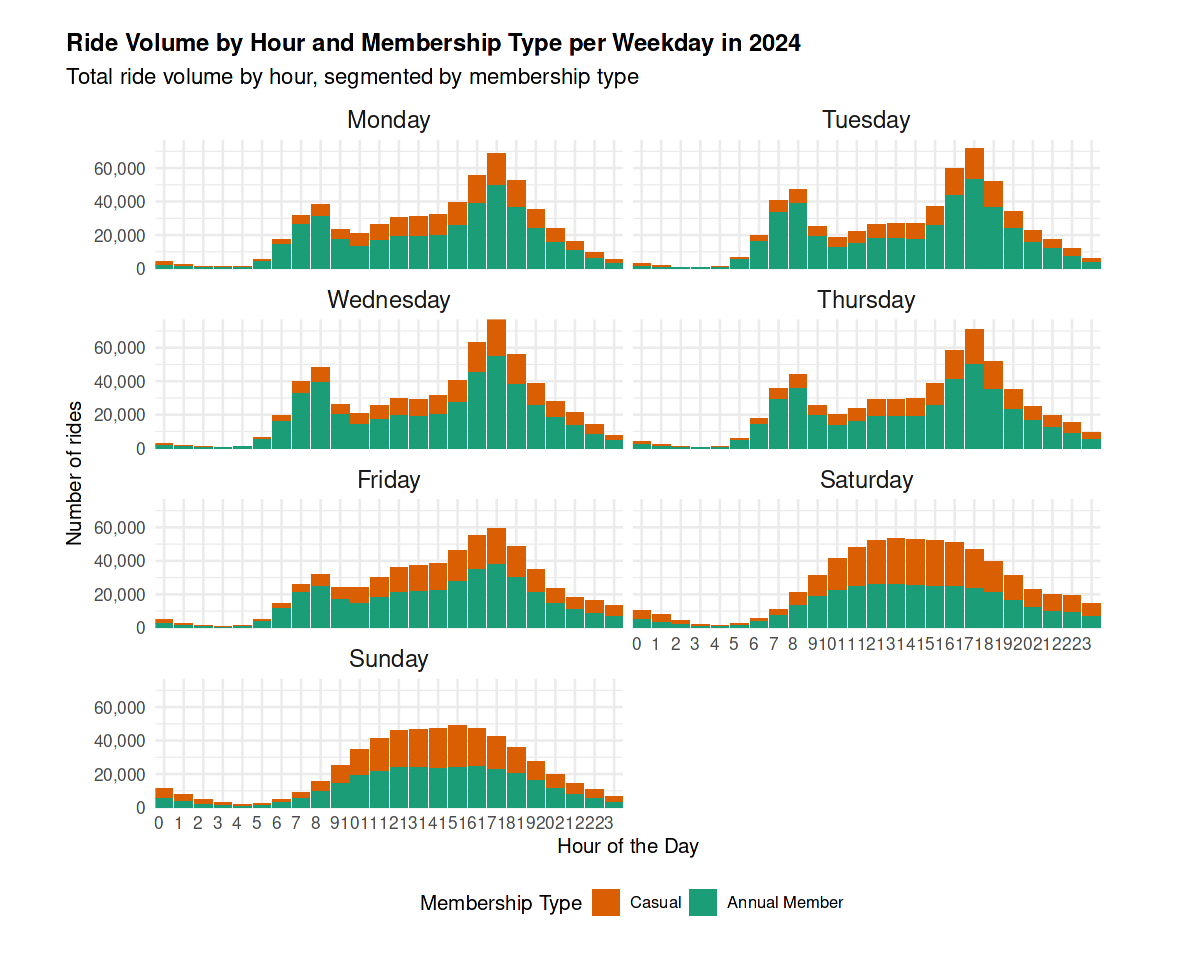

In [12]:
# Stacked Bar Chart of Ride Volume by Hour and Weekday 

# Compute ride count per hour, weekday, and member type 
hourly_weekday_count <- cyclistic_24 %>%
  mutate(hour = lubridate::hour(started_at)) %>%
  group_by(hour, weekday, member_casual) %>%
  summarise(ride_count = n(), .groups = "drop")

#ensuring the plots order of the weekdays
hourly_weekday_count$weekday <- factor(
  hourly_weekday_count$weekday,
  levels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"),
  ordered = TRUE
)

# Set plot dimensions for this specific plot
options(repr.plot.width = 10, repr.plot.height = 8)

# Plot: Stacked Bar Chart of Ride Volume by Hour and Weekday
ggplot(hourly_weekday_count, aes(x = factor(hour), y = ride_count, fill = member_casual)) +
  geom_bar(stat = "identity") +   # Stacked bar chart

  labs(
    title = "Ride Volume by Hour and Membership Type per Weekday in 2024",
    subtitle = "Total ride volume by hour, segmented by membership type",
    x = "Hour of the Day",
    y = "Number of rides",
    fill = "Membership Type"
  ) +

  scale_fill_manual(
    values = c("casual" = "#d95f02", "member" = "#1b9e77"),
    labels = c("Casual", "Annual Member")
  ) +

  scale_y_continuous(labels = scales::label_comma()) +

  theme_minimal(base_size = 12) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",
    plot.margin = margin(20, 60, 20, 40),
    strip.text = element_text(size = 14),  # Larger weekday labels
    axis.text.x = element_text(size = 10, hjust = 1),  # Smaller hour labels on x-axis
    axis.text.y = element_text(size = 10)   # Adjust y-axis text size
  ) +

  facet_wrap(~ weekday, ncol = 2) +  # Facet by weekday with 3 columns for better layout
  coord_cartesian(expand = FALSE)  # Remove extra space around the plot

# Save the plot with larger dimensions for better readability
ggsave("ride_volume_plot.png", width = 20, height = 40, dpi = 300, limitsize = FALSE)



These plots reflect the volume of rides per hour for each day of the week, and here we get a confirmation on what was stated above, that during the working days, the morning periods from 7am-9am and afternoon periods from 4pm-6pm have higher values. Nevertheless, we notice that during the weekend, the number of rides and especially from casual members are higher, and remain slightly consistent from 11 am until 6pm. This could aggregate the rides that have more spare time during the weekend and use it for a ride.

### 4.2 Analysing Ride Duration

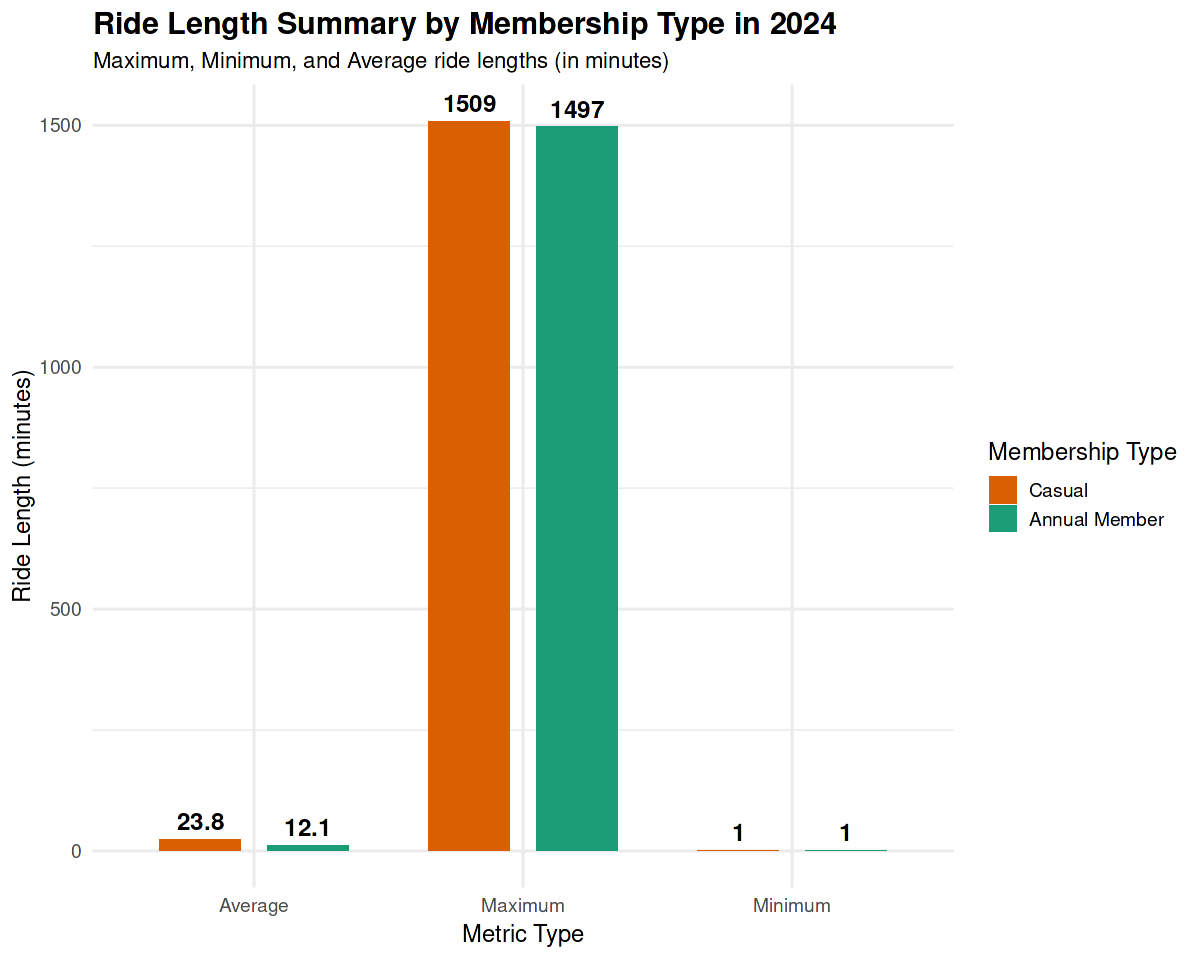

In [13]:
# Summary of ride length stats by member type
ride_length_summary <- cyclistic_24 %>%
  group_by(member_casual) %>%
  summarise(
    max_ride_length  = max(ride_length, na.rm = TRUE),
    min_ride_length  = min(ride_length, na.rm = TRUE),
    avg_ride_length  = mean(ride_length, na.rm = TRUE)
  )

#plot
# Reshape data from wide → long for plotting
ggplot(ride_length_summary) +
  geom_col(aes(x = "Maximum", y = max_ride_length, fill = member_casual),
           position = position_dodge(width = 0.8), width = 0.6) +
  geom_col(aes(x = "Minimum", y = min_ride_length, fill = member_casual),
           position = position_dodge(width = 0.8), width = 0.6) +
  geom_col(aes(x = "Average", y = avg_ride_length, fill = member_casual),
           position = position_dodge(width = 0.8), width = 0.6) +

  # Add text labels on top of bars
  geom_text(aes(x = "Maximum", y = max_ride_length, label = round(max_ride_length, 1), group = member_casual),
            position = position_dodge(width = 0.8), vjust = -0.5, size = 5, fontface = "bold") +
  geom_text(aes(x = "Minimum", y = min_ride_length, label = round(min_ride_length, 1), group = member_casual),
            position = position_dodge(width = 0.8), vjust = -0.5, size = 5, fontface = "bold") +
  geom_text(aes(x = "Average", y = avg_ride_length, label = round(avg_ride_length, 1), group = member_casual),
            position = position_dodge(width = 0.8), vjust = -0.5, size = 5, fontface = "bold") +

  # Labels and theme
  labs(
    title = "Ride Length Summary by Membership Type in 2024",
    subtitle = "Maximum, Minimum, and Average ride lengths (in minutes)",
    x = "Metric Type",
    y = "Ride Length (minutes)",
    fill = "Membership Type"
  ) +
  scale_fill_manual(values = c("casual" = "#d95f02", "member" = "#1b9e77"),
                    labels = c("Casual", "Annual Member")) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "right"
  )

This plot reflects the summary by membership type, in which we can see that  although both have long-duration rides, the casual members seem to have a significantly higher number of long rides, which is reflected in their high average value of 23.8 min per ride against 12.1 min average ride from the annual members. 

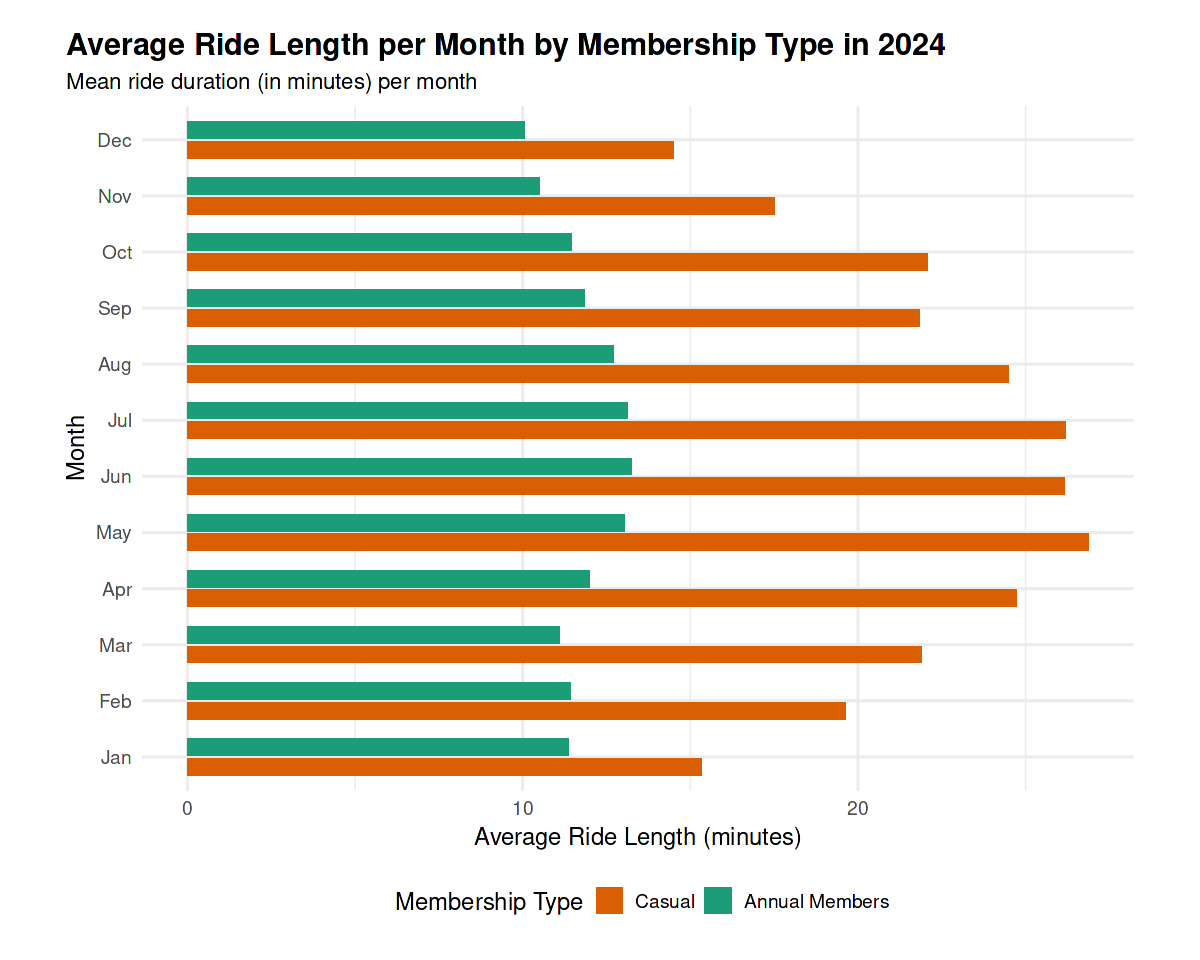

In [14]:
# Average ride length
avg_ride_length_month <- cyclistic_24 %>%
  mutate(month = month(month)) %>%
  group_by(month, member_casual) %>%
  summarise(avg_ride_length = mean(ride_length, na.rm = TRUE), .groups = "drop") %>%
  mutate(
    month = factor(month, levels = 1:12, labels = month.abb, ordered = TRUE)
  )

#AVG ride length plot
ggplot(avg_ride_length_month, aes(x = month, y = avg_ride_length, fill = member_casual)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +

  labs(
    title = "Average Ride Length per Month by Membership Type in 2024",
    subtitle = "Mean ride duration (in minutes) per month",
    x = "Month",
    y = "Average Ride Length (minutes)",
    fill = "Membership Type"
  ) +

  scale_fill_manual(
    values = c("casual" = "#d95f02", "member" = "#1b9e77"),
    labels = c("Casual", "Annual Members")
  ) +

  scale_y_continuous(labels = label_comma()) +

  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",
    plot.margin = margin(20, 40, 20, 40)
  ) +

coord_flip() 

As previously mentioned, the casual riders on average ride for longer periods of time, having higher peaks in Summer, while the average ride duration for the annual members remains constant throughout the year, with a slight increase in the summer. This could reflect that the annual membership is used for shorter rides. For a better understanding, breaking down the ride duration into segments could enable a better analysis.

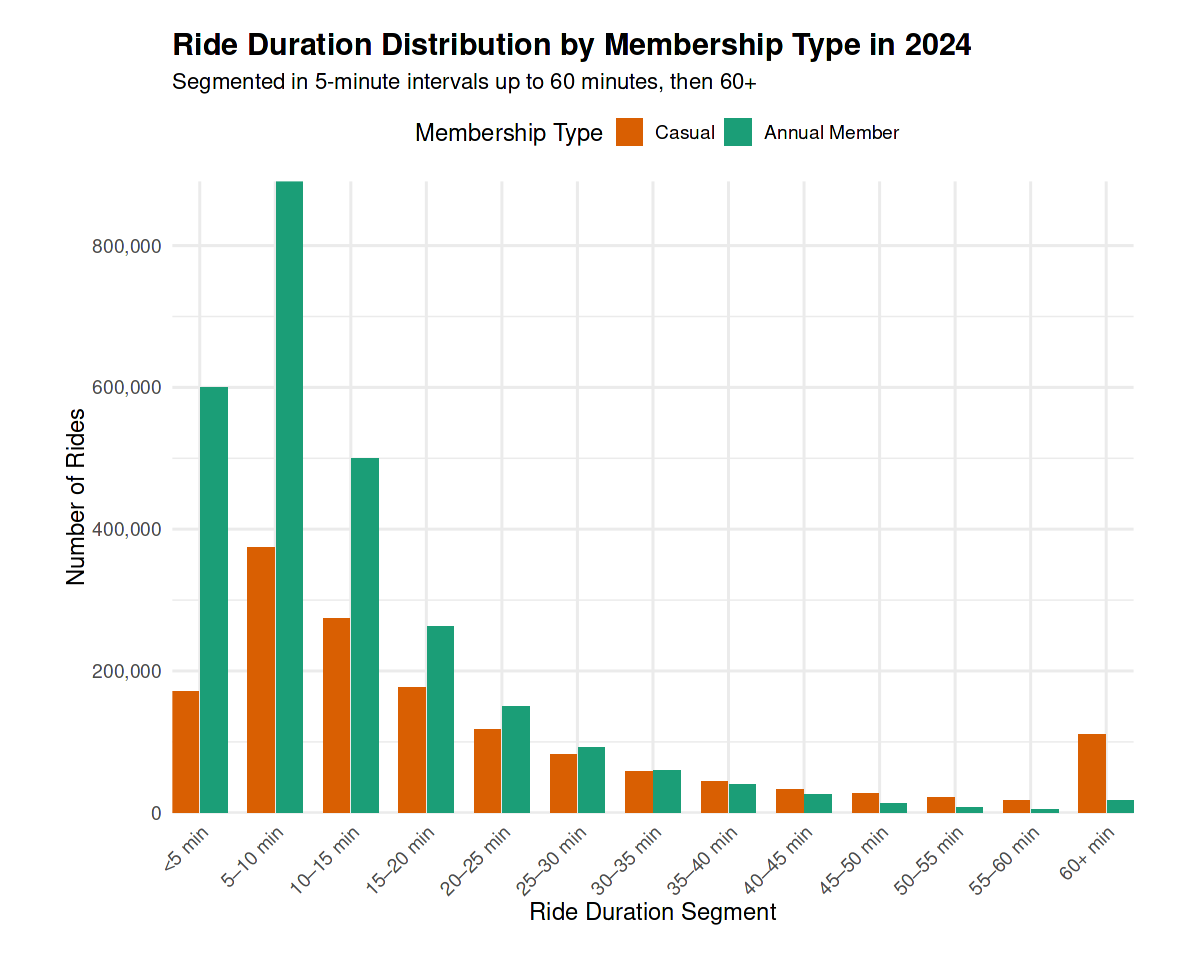

In [15]:
# Creating dataset for ride duration distribution by segment and membership type
ride_length_distribution <- cyclistic_24 %>%
  mutate(
    duration_segment = case_when(
      ride_length < 5 ~ "<5 min",
      ride_length >= 5 & ride_length < 10 ~ "5–10 min",
      ride_length >= 10 & ride_length < 15 ~ "10–15 min",
      ride_length >= 15 & ride_length < 20 ~ "15–20 min",
      ride_length >= 20 & ride_length < 25 ~ "20–25 min",
      ride_length >= 25 & ride_length < 30 ~ "25–30 min",
      ride_length >= 30 & ride_length < 35 ~ "30–35 min",
      ride_length >= 35 & ride_length < 40 ~ "35–40 min",
      ride_length >= 40 & ride_length < 45 ~ "40–45 min",
      ride_length >= 45 & ride_length < 50 ~ "45–50 min",
      ride_length >= 50 & ride_length < 55 ~ "50–55 min",
      ride_length >= 55 & ride_length < 60 ~ "55–60 min",
      ride_length >= 60 ~ "60+ min"
    )
  ) %>%
  group_by(duration_segment, member_casual) %>%
  summarise(total_rides = n(), .groups = "drop")


# - Organize duration_segment by a predefined order -
ride_length_distribution$duration_segment <- factor(
  ride_length_distribution$duration_segment,
  levels = c("<5 min", "5–10 min", "10–15 min", "15–20 min", 
             "20–25 min", "25–30 min", "30–35 min", "35–40 min", 
             "40–45 min", "45–50 min", "50–55 min", "55–60 min", "60+ min"),
  ordered = TRUE
    )

# - Plot: Ride Duration Distribution by Membership Type -
ggplot(ride_length_distribution, aes(x = duration_segment, y = total_rides, fill = member_casual)) +
  geom_col(position = position_dodge(width = 0.75), width = 0.7) +
  labs(
    title = "Ride Duration Distribution by Membership Type in 2024",
    subtitle = "Segmented in 5-minute intervals up to 60 minutes, then 60+",
    x = "Ride Duration Segment",
    y = "Number of Rides",
    fill = "Membership Type"
  ) +
  scale_fill_manual(
    values = c("casual" = "#d95f02", "member" = "#1b9e77"),
    labels = c("Casual", "Annual Member")
  ) +
  scale_y_continuous(labels = scales::label_comma()) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "top",
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.margin = margin(20, 40, 20, 40)
  ) +
  coord_cartesian(expand = FALSE)


In this plot, we can see that the highest volume of rides happens between rides under 5 min and rides under 15 min. This plot confirms what was being suggested before, that the annual members tend to ride more in shorter periods of time, having the highest volumes of rides lasting between 5 to 10 min. The segment 5 to 10 min of ride also has the highest volume of casual members' rides. At the same time, after 35-40 min the volume of casual members' rides surpasses the annual members, and has a significant increase in rides with over 60 min long.
Also, it is important to distinguish the lowest amounts of rides the annual members have between 50-60 min segments. This could suggest that the end of the free duration allowance ends here, although difficult to conclude as there are some ride

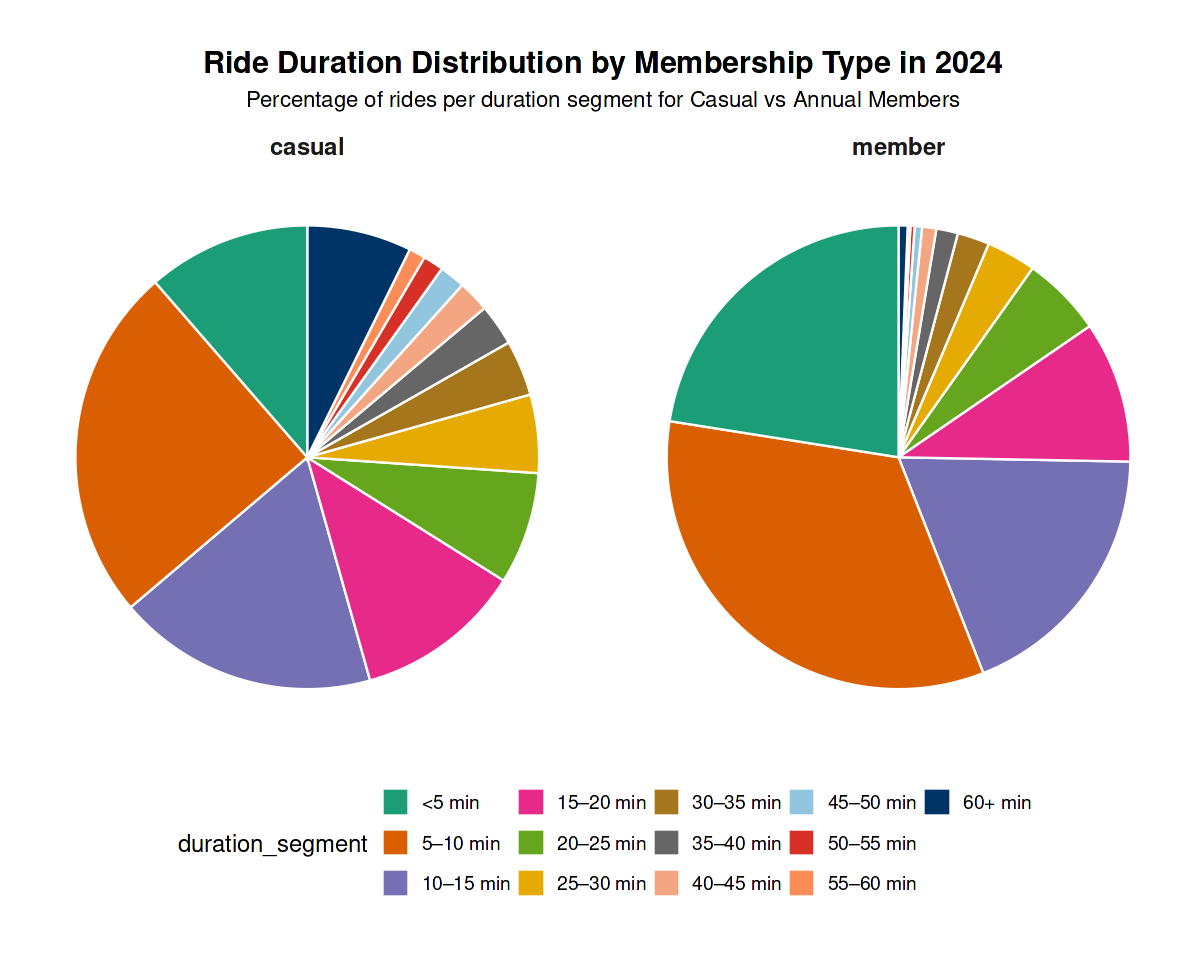

In [16]:
# Create dataset for ride duration distribution by segment and membership type 
ride_length_distribution <- cyclistic_24 %>%
  mutate(
    duration_segment = case_when(
      ride_length < 5 ~ "<5 min",
      ride_length >= 5 & ride_length < 10 ~ "5–10 min",
      ride_length >= 10 & ride_length < 15 ~ "10–15 min",
      ride_length >= 15 & ride_length < 20 ~ "15–20 min",
      ride_length >= 20 & ride_length < 25 ~ "20–25 min",
      ride_length >= 25 & ride_length < 30 ~ "25–30 min",
      ride_length >= 30 & ride_length < 35 ~ "30–35 min",
      ride_length >= 35 & ride_length < 40 ~ "35–40 min",
      ride_length >= 40 & ride_length < 45 ~ "40–45 min",
      ride_length >= 45 & ride_length < 50 ~ "45–50 min",
      ride_length >= 50 & ride_length < 55 ~ "50–55 min",
      ride_length >= 55 & ride_length < 60 ~ "55–60 min",
      ride_length >= 60 ~ "60+ min"
    )
  ) %>%
  group_by(duration_segment, member_casual) %>%
  summarise(total_rides = n(), .groups = "drop") %>%
  group_by(member_casual) %>%
  mutate(percentage = total_rides / sum(total_rides) * 100) %>%
  ungroup()

# - Order segments chronologically -
ride_length_distribution$duration_segment <- factor(
  ride_length_distribution$duration_segment,
  levels = c("<5 min", "5–10 min", "10–15 min", "15–20 min", 
             "20–25 min", "25–30 min", "30–35 min", "35–40 min", 
             "40–45 min", "45–50 min", "50–55 min", "55–60 min", "60+ min"),
  ordered = TRUE
)


# Custom color palette with more colors
custom_colors <- c("#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02", 
                   "#a6761d", "#666666", "#f4a582", "#92c5de", "#d73027", "#fc8d59", 
                   "#003366", "#4575b4", "#313695", " #a6761d")  # New color for 45-50 min and 60+ min

# - Plot: Two Pie Charts (one per membership type) showing percentage -
ggplot(ride_length_distribution, aes(x = "", y = percentage, fill = duration_segment)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar(theta = "y") +

  facet_wrap(~ member_casual, ncol = 2) +  # Separate pie charts for each membership type
  scale_fill_manual(values = custom_colors) +  # Use custom color palette
  labs(
    title = "Ride Duration Distribution by Membership Type in 2024",
    subtitle = "Percentage of rides per duration segment for Casual vs Annual Members",
    x = NULL,
    y = NULL
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
    plot.subtitle = element_text(size = 13, hjust = 0.5),
    legend.position = "bottom",
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    strip.text = element_text(size = 14, face = "bold")
  )


According to the pie charts above, we can see that as the duration increases the volume of rides decrease, however, if we see the segment of +60 min we can see that the casual members have a higher volume of rides than the annual members. This is better represented in the table below, where we can see that this segment represents 7.3% of the total rides of the casual member rides, and 2,6% for the total rides overall. Differently, for the annual members, this represents 0.6% of the total rides of the annual members and 0.4% for the total rides overall.

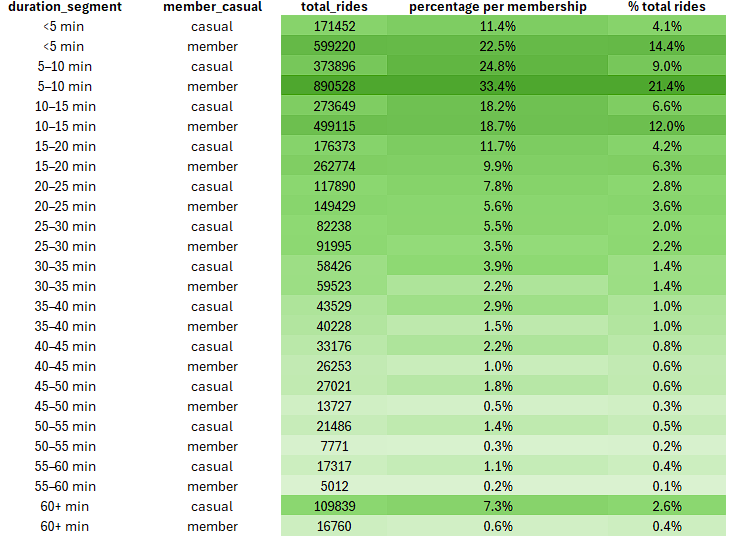



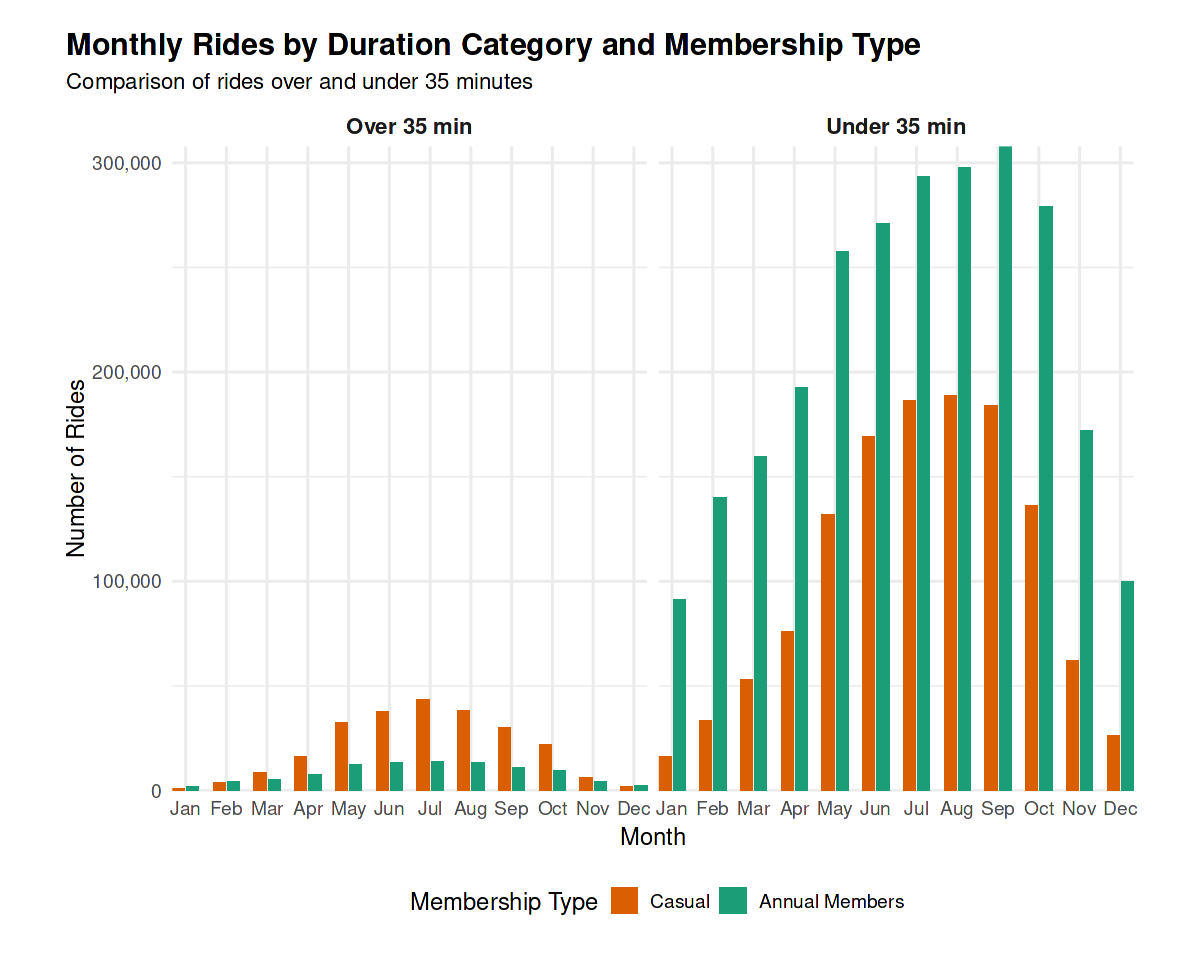

In [17]:
# Volume of Rides with duration over 35 min vs under 35 min
long_rides_over_35 <- cyclistic_24 %>%
  filter(ride_length > 35) %>%
  mutate(
    month = month(month),  # Use started_at to extract month
    ride_category = "Over 35 min"
  ) %>%
  group_by(month, member_casual, ride_category) %>%
  summarise(total_rides = n(), .groups = "drop") %>%
  mutate(month = factor(month, levels = 1:12, labels = month.abb, ordered = TRUE))

# - Rides under 35 min -
long_rides_less_35 <- cyclistic_24 %>%
  filter(ride_length <= 35) %>%
  mutate(
    month = month(month),
    ride_category = "Under 35 min"
  ) %>%
  group_by(month, member_casual, ride_category) %>%
  summarise(total_rides = n(), .groups = "drop") %>%
  mutate(month = factor(month, levels = 1:12, labels = month.abb, ordered = TRUE))

# - Combine datasets -
combined_rides <- bind_rows(long_rides_over_35, long_rides_less_35)

# - Plot: Facet Wrap -
ggplot(combined_rides, aes(x = month, y = total_rides, fill = member_casual)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  facet_wrap(~ ride_category) +
  labs(
    title = "Monthly Rides by Duration Category and Membership Type",
    subtitle = "Comparison of rides over and under 35 minutes",
    x = "Month",
    y = "Number of Rides",
    fill = "Membership Type"
  ) +
  scale_fill_manual(
    values = c("casual" = "#d95f02", "member" = "#1b9e77"),
    labels = c("Casual", "Annual Members")
  ) +
  scale_y_continuous(labels = scales::label_comma()) +
  theme_minimal(base_size = 14) +
  theme(
    strip.text = element_text(face = "bold", size = 13),
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",
    plot.title.position = "plot",
    plot.margin = margin(20, 40, 20, 40)
  ) +
  coord_cartesian(expand = FALSE)


As per the bar chart 'Ride Duration Distribution by Membership Type in 2024', the 45 min could be the breaking point in which it's more valuable to have a casual membership rather than being an annual member. Unfortunately, we cannot develop our analysis on this hypothesis as we have no access to any monetary value in this scenario. But we can use this period up to 35 min as the ideal target for casual members to acquire an annual membership. 

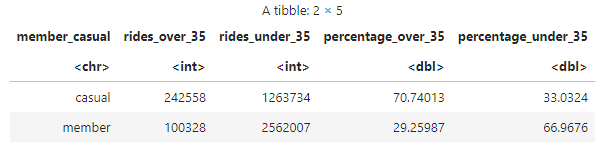

As per the above table, we can see that 33% of the rides with a duration under 35 min were done by casual members. This number can be associated with the potential value to analyse how many people could be converted to annual members.

**Note:** 35 min segment was chosen for being a moment where the volume of casual member rides surpasses the annual members.

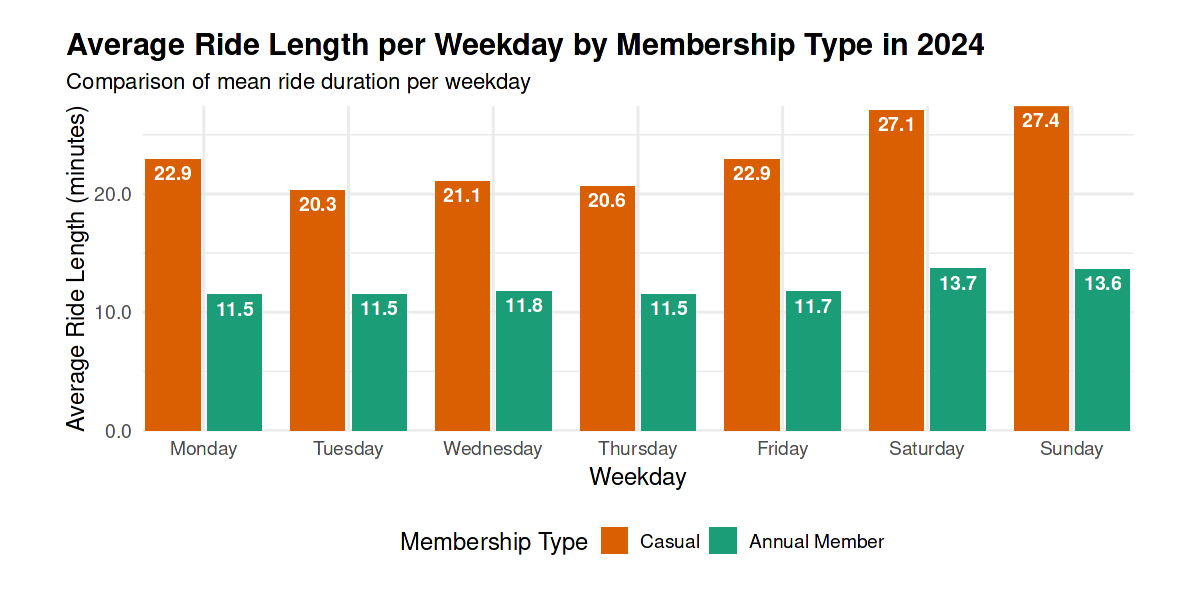

In [18]:
# Compute average ride length per weekday
weekday_avg_length <- cyclistic_24 %>%
  group_by(weekday, member_casual) %>%
  summarise(avg_ride_length = mean(ride_length, na.rm = TRUE), .groups = "drop")

weekday_avg_length$weekday <- factor(
  weekday_avg_length$weekday,
  levels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"),
  ordered = TRUE
)

# - Plot: Average Ride Length per Weekday -
p1 <- ggplot(weekday_avg_length, aes(x = weekday, y = avg_ride_length, fill = member_casual)) +
  geom_col(position = position_dodge(width = 0.85), width = 0.75) +  # 🔧 reduced gap between bars
  
  # Add text labels inside bars
  geom_text(
    aes(label = round(avg_ride_length, 1)),
    position = position_dodge(width = 0.85),
    vjust = 1.5,          
    size = 4,
    fontface = "bold",
    color = "white"
  ) +
  
  labs(
    title = "Average Ride Length per Weekday by Membership Type in 2024",
    subtitle = "Comparison of mean ride duration per weekday",
    x = "Weekday",
    y = "Average Ride Length (minutes)",
    fill = "Membership Type"
  ) +
  scale_fill_manual(
    values = c("casual" = "#d95f02", "member" = "#1b9e77"),
    labels = c("Casual", "Annual Member")
  ) +
  scale_y_continuous(
    labels = label_number(accuracy = 0.1),
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",
    plot.margin = margin(20, 40, 20, 40)
  ) +
  coord_cartesian(expand = FALSE)

options(repr.plot.width = 10, repr.plot.height = 5)
print(p1)


In this plot, we understand that not only the casual members ride for a longer time than the annual members but they also ride longer at the weekends. Regarding the annual members, it is noticeable a tendency to ride for longer times during the weekends, which is an interesting correlation with the casual members and could be a point to explore to track those casual members who ride more on the weekend and turn them into annual members.

Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_col()`).”


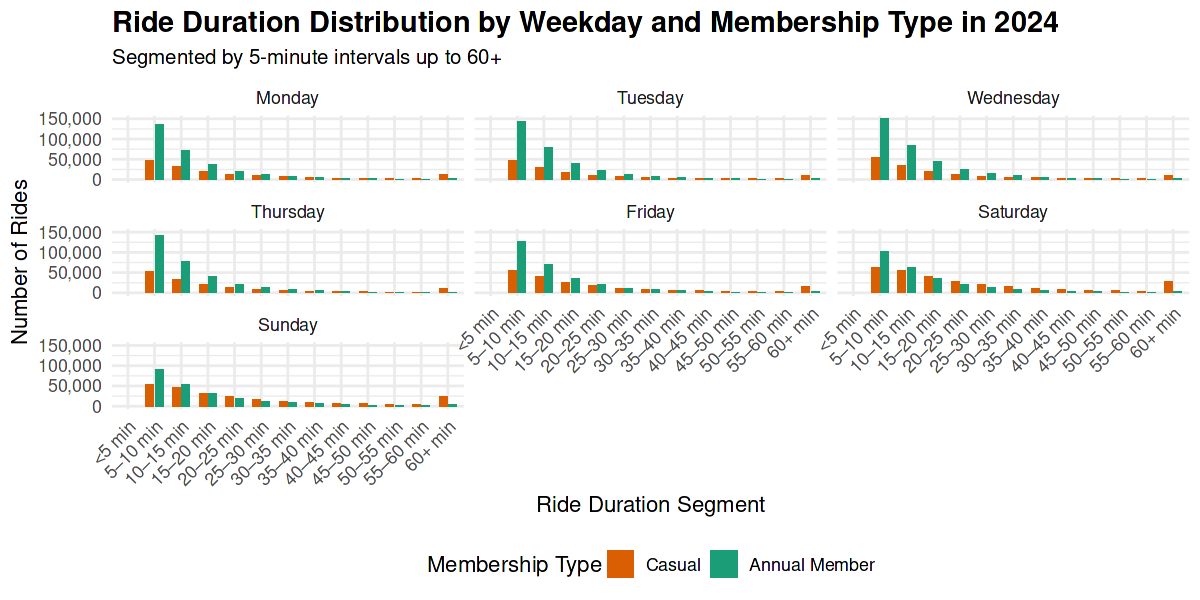

In [19]:
# Distribution of ride duration volume by weekday and membership type 
weekday_duration_distribution <- cyclistic_24 %>%
  mutate(
    duration_segment = case_when(
      ride_length < 5 ~ "< 5 min",
     ride_length >= 5 & ride_length < 10 ~ "5–10 min",
      ride_length >= 10 & ride_length < 15 ~ "10–15 min",
      ride_length >= 15 & ride_length < 20 ~ "15–20 min",
      ride_length >= 20 & ride_length < 25 ~ "20–25 min",
      ride_length >= 25 & ride_length < 30 ~ "25–30 min",
      ride_length >= 30 & ride_length < 35 ~ "30–35 min",
      ride_length >= 35 & ride_length < 40 ~ "35–40 min",
      ride_length >= 40 & ride_length < 45 ~ "40–45 min",
      ride_length >= 45 & ride_length < 50 ~ "45–50 min",
      ride_length >= 50 & ride_length < 55 ~ "50–55 min",
      ride_length >= 55 & ride_length < 60 ~ "55–60 min",
      ride_length >= 60 ~ "60+ min"
    )
  ) %>%
  group_by(weekday, member_casual, duration_segment) %>%
  summarise(total_rides = n(), .groups = "drop")

# Ensure weekday order from Monday to Sunday
weekday_duration_distribution$weekday <- factor(
  weekday_duration_distribution$weekday,
  levels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"),
  ordered = TRUE
)

# Pivot the data to have total_rides for each membership type in separate columns
weekday_duration_distribution_wide <- weekday_duration_distribution %>%
  pivot_wider(
    names_from = member_casual,   # Create columns for 'casual' and 'member'
    values_from = total_rides,     # The total rides for each membership type
      # Fill missing values with 0 if there are any missing combinations
  )

# - Ordering duration segments correctly -
weekday_duration_distribution_wide$duration_segment <- factor(
  weekday_duration_distribution_wide$duration_segment,
  levels = c("< 5 min", "5–10 min", "10–15 min", "15–20 min", 
             "20–25 min", "25–30 min", "30–35 min", "35–40 min", 
             "40–45 min", "45–50 min", "50–55 min", "55–60 min", "60+ min"),
  ordered = TRUE
)

# Arrange by weekday and duration segment
weekday_duration_distribution_wide <- weekday_duration_distribution_wide %>%
  arrange(weekday, duration_segment)

# Plot of the ride duration for each day of the week
ggplot(weekday_duration_distribution, 
       aes(x = duration_segment, y = total_rides, fill = member_casual)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  facet_wrap(~ weekday, ncol = 3) +
  labs(
    title = "Ride Duration Distribution by Weekday and Membership Type in 2024",
    subtitle = "Segmented by 5-minute intervals up to 60+",
    x = "Ride Duration Segment",
    y = "Number of Rides",
    fill = "Membership Type"
  ) +
  scale_fill_manual(
    values = c("casual" = "#d95f02", "member" = "#1b9e77"),
    labels = c("Casual", "Annual Member")
  ) +
  scale_y_continuous(labels = scales::label_comma()) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 17),
    plot.subtitle = element_text(size = 12),
    legend.position = "bottom",
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  # Ensure the segments are ordered correctly (small to large)
  scale_x_discrete(
    limits = c("<5 min", "5–10 min", "10–15 min", "15–20 min",
               "20–25 min", "25–30 min", "30–35 min", "35–40 min",
               "40–45 min", "45–50 min", "50–55 min", "55–60 min", "60+ min")
  )


Furthermore, with these charts, it is possible to have a better perspective on the volumes of the ride durations across the week, where it is observable a consistent pattern between both volume and ride duration from Monday to Friday, not changing much between those days. The segment under 5 min had the highest volume on rides for both casual and annual members. During the weekend, there was a small decrease on the rides overall rides for the annual members and in contrast, the casual members had an overall increase across many segments in particular from under 5 min to 25 min, and they had also a notable increase for the rides longer than 60 min, concluding that these longer rides tend to happen the most during the weekends.

### 4.3 Analysing Type of Rides

#### 4.3.1 Overview of the Type of Rides

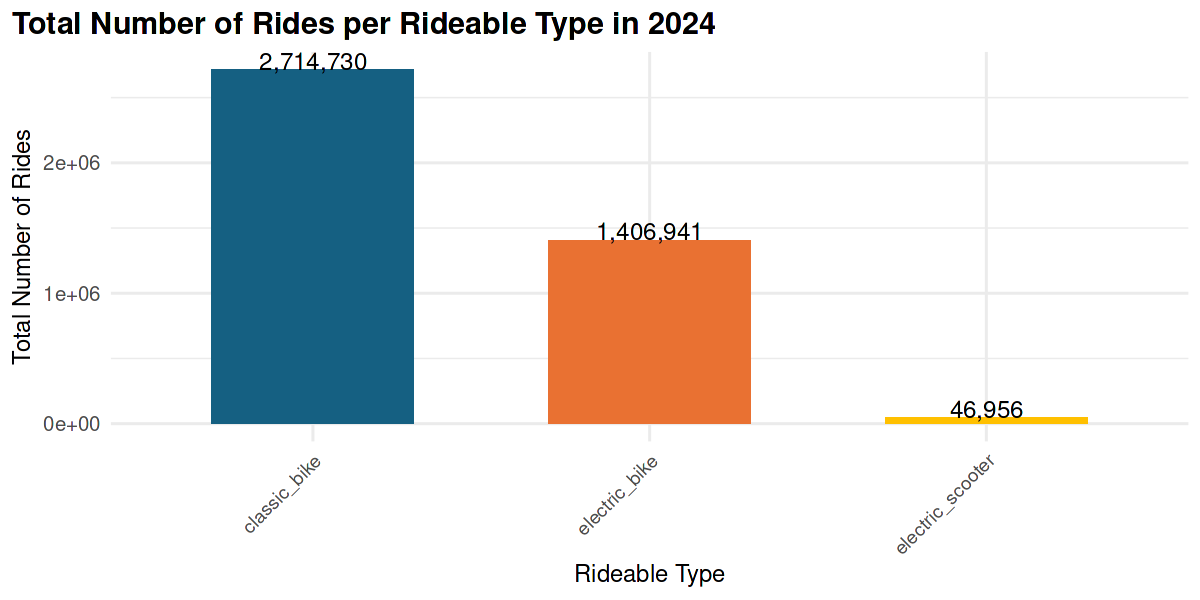

In [20]:
# Total ride volume by rideable_type 
total_rideable_type_rides <- cyclistic_24 %>%
  group_by(rideable_type) %>%
  summarise(total_rides = n(), .groups = "drop")

# Plot: Total Ride Volume by Rideable Type 
ggplot(total_rideable_type_rides, aes(x = rideable_type, y = total_rides, fill = rideable_type)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.6) +  # Side-by-side bars for each rideable type
  geom_text(
    aes(label = scales::label_comma()(total_rides)),  # Nicely formatted numbers
    colour = "black",  # Text color inside the bar
    size = 5,
    position = position_dodge(width = 0.6),  # Ensure text is aligned with the bars
    vjust = 0  # Place the text just above the bars
  ) +
  labs(
    title = "Total Number of Rides per Rideable Type in 2024",
    x = "Rideable Type",
    y = "Total Number of Rides"
  ) +
  scale_fill_manual(values = c("classic_bike" = "#156082", "electric_bike" = "#E97132", "electric_scooter" = "#FFC000")) +  # Custom colors for rideable types
  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for better readability
    axis.text.y = element_text(size = 12),
    axis.ticks.y = element_blank(),  # Remove y-axis ticks
    legend.position = "none"  # No legend needed for this plot
  )


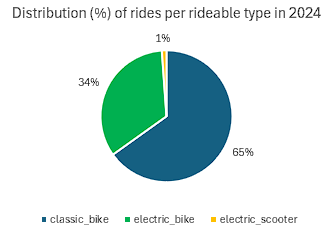

Considering the overall volume of rides, 65% were rides using classic bikes, reflecting a higher tendency to use casual bikes; 34% using the electric bikes and 1% using electric scooters. Assessing this distribution per membership type will enable an understanding of how casual members and annual members use these three rideable types.

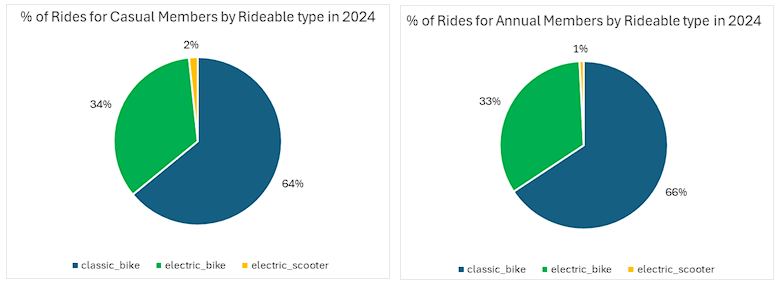


In the percentage of rideable types' distribution per membership type, we can see that casual bikes take the lead as the preferred rideable type by both casual and annual members representing 64% and 66% respectively. Then, followed by the electric bikes with 34% and 33% respectively. In terms of shared distribution, it's interesting that both casual and annual members have a very similar representation.

rideable_type,member_casual,total_rides
<chr>,<chr>,<int>
classic_bike,casual,965094
classic_bike,member,1749636
electric_bike,casual,515919
electric_bike,member,891022
electric_scooter,casual,25279
electric_scooter,member,21677


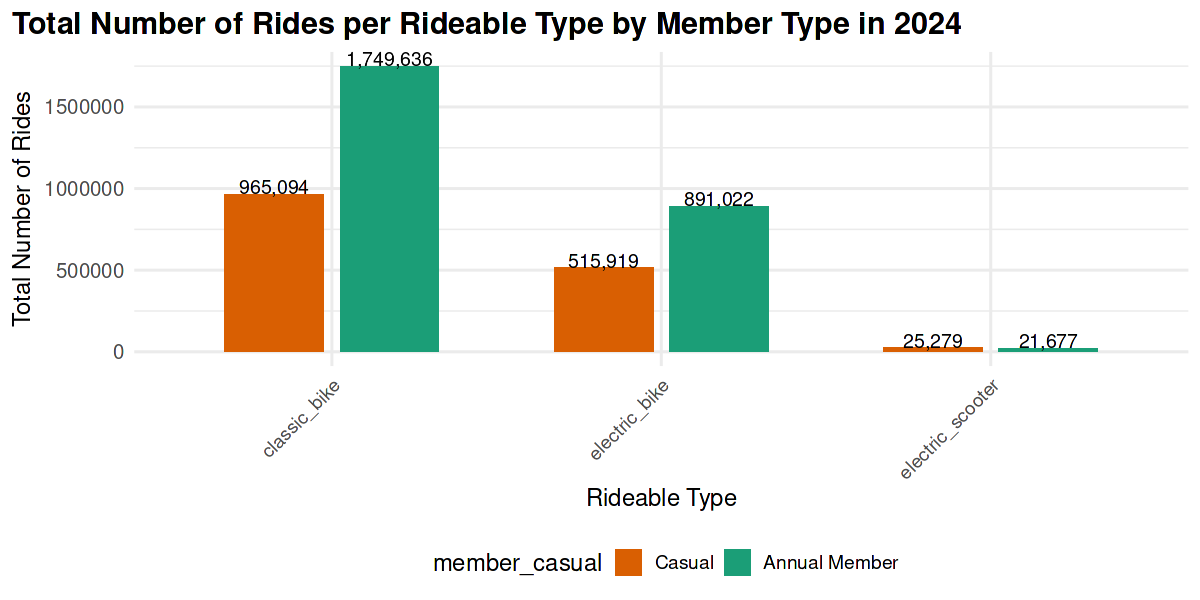

In [21]:
# Calculate total ride volume by rideable_type and member_casual 
ride_volume_by_type <- cyclistic_24 %>%
  group_by(rideable_type, member_casual) %>%
  summarise(total_rides = n(), .groups = "drop")

ride_volume_by_type

# Plot: Total Ride Volume by Rideable Type and Member Type 
ggplot(ride_volume_by_type, aes(x = rideable_type, y = total_rides, fill = member_casual)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.7), width = 0.6) +  # Side-by-side bars for each member type
  geom_text(
    aes(label = scales::label_comma()(total_rides)),  # Nicely formatted numbers
    colour = "black",
    size = 4,
    position = position_dodge(width = 0.7),  # Ensure text is aligned with the bars
    vjust = 0  # Center the text vertically inside the bars
  ) +
  labs(
    title = "Total Number of Rides per Rideable Type by Member Type in 2024",
    x = "Rideable Type",
    y = "Total Number of Rides"
  ) +
  scale_fill_manual(values = c("casual" = "#d95f02", "member" = "#1b9e77"),
                    labels = c("Casual", "Annual Member")) +  # Custom colors for membership types
  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",  # Move legend to the bottom
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    axis.text.y = element_text(size = 12),
    axis.ticks.y = element_blank(),  # Remove y-axis ticks
    strip.text = element_text(size = 14)  # Larger facet labels
  )

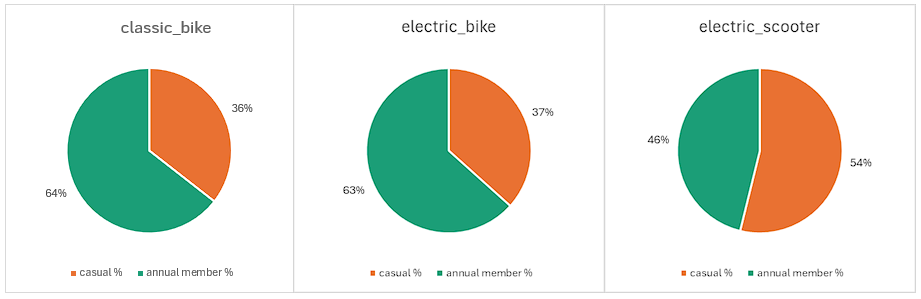




In terms of volume of rides, we see annual members with a significantly higher volume of rides than the casual members, in both casual bikes and electric bikes, having the annual members 64% and 63% respectively. Nevertheless, the electric scooter, although it had a lower volume of rides, the casual members had 8% more rides than the annual members.

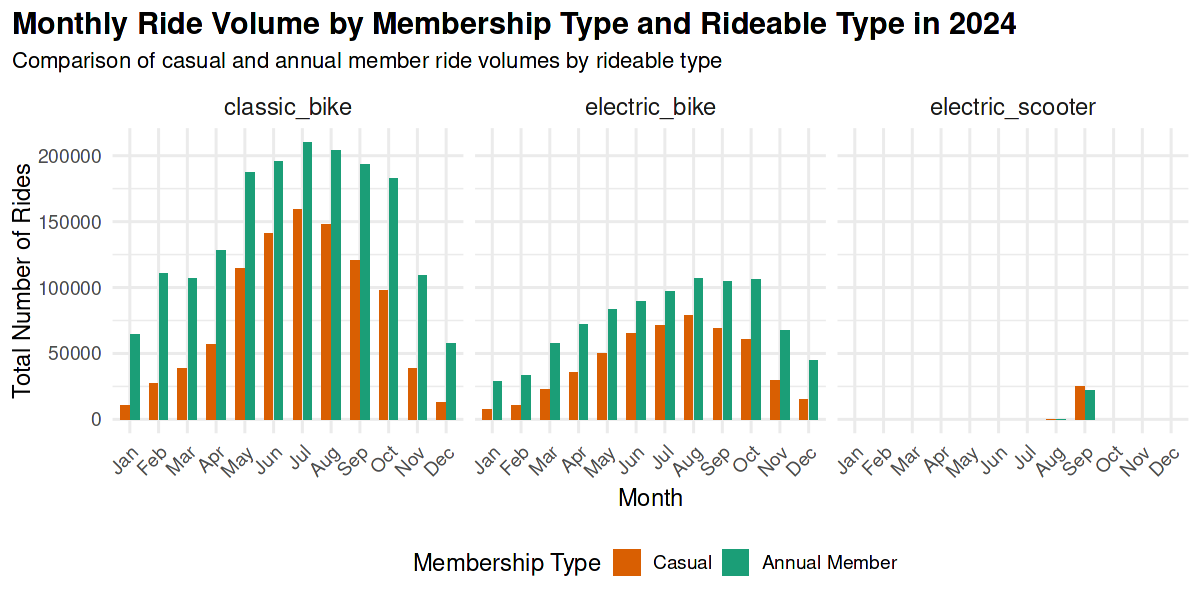

In [22]:
# Calculate total ride volume by month, membership type, and rideable type 
monthly_ride_volume <- cyclistic_24 %>%
  group_by(month, rideable_type, member_casual) %>%
  summarise(total_rides = n(), .groups = "drop") %>%
  mutate(
    month = factor(month, levels = 1:12, labels = month.abb, ordered = TRUE)  # Convert month to labels (Jan-Dec)
  )

# Plot: Monthly Ride Volume by Membership Type and Rideable Type 
ggplot(monthly_ride_volume, aes(x = month, y = total_rides, fill = member_casual)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.7), width = 0.6) +  # Side-by-side bars for each member type
  labs(
    title = "Monthly Ride Volume by Membership Type and Rideable Type in 2024",
    subtitle = "Comparison of casual and annual member ride volumes by rideable type",
    x = "Month",
    y = "Total Number of Rides",
    fill = "Membership Type"
  ) +
  scale_fill_manual(values = c("casual" = "#d95f02", "member" = "#1b9e77"),
                    labels = c("Casual", "Annual Member")) +  # Custom colors for membership types
  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(size = 14)  # Larger facet labels for rideable types
  ) +
  # Facet by rideable type (classic_bike, electric_bike, electric_scooter)
  facet_wrap(~ rideable_type, scales = "fixed")  # Separate by rideable type


Starting with the electric scooter, and considering they were available for just around 1 month and for that reason it should be excluded from our analysis.

In terms of volume of rides, the annual members had higher volumes of rides than the casual members across all years. Additionally, it is notable that the peak of volume for both casual bikes and electric bikes is during May until October, reflecting the  Summer and the middle of Fall seasons, having a significant decrease during Winter times.

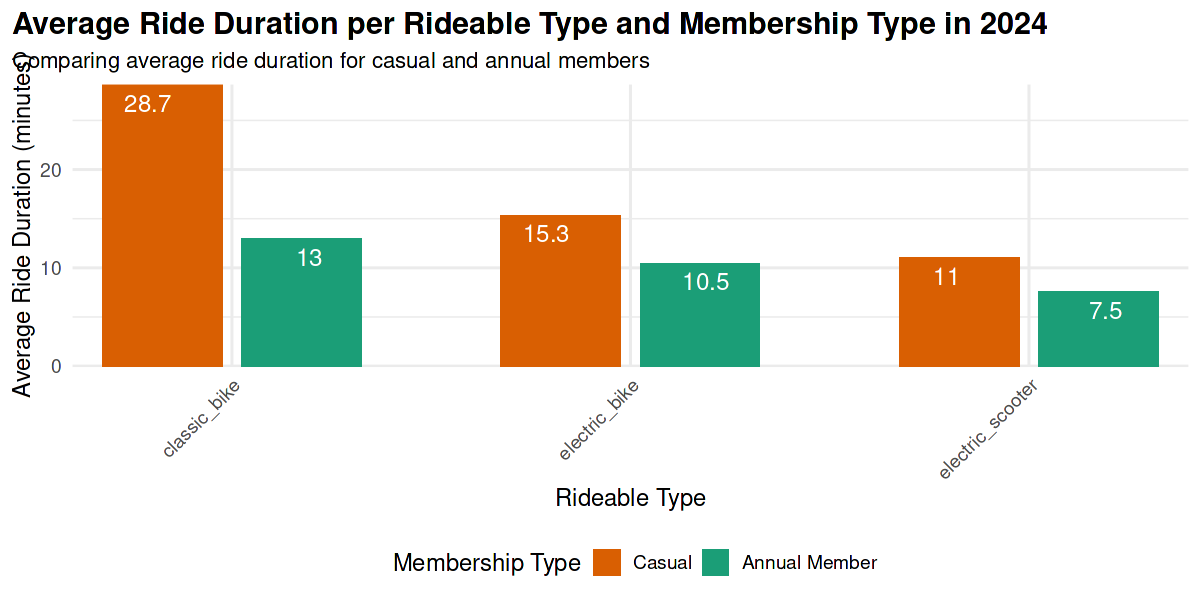

In [23]:
# Calculate the average ride duration by rideable_type and member_casual
avg_ride_duration_by_type <- cyclistic_24 %>%
  group_by(rideable_type, member_casual) %>%
  summarise(avg_ride_duration = mean(ride_length, na.rm = TRUE), .groups = "drop")

# Plot: Average Ride Duration per Rideable Type and Membership Type 
ggplot(avg_ride_duration_by_type, aes(x = rideable_type, y = avg_ride_duration, fill = member_casual)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.7), width = 0.6) +  # Bar chart with dodged bars for each membership type
  labs(
    title = "Average Ride Duration per Rideable Type and Membership Type in 2024",
    subtitle = "Comparing average ride duration for casual and annual members",
    x = "Rideable Type",
    y = "Average Ride Duration (minutes)",
    fill = "Membership Type"
  ) +
  scale_fill_manual(values = c("casual" = "#d95f02", "member" = "#1b9e77"),
                    labels = c("Casual", "Annual Member")) +  # Customize colors for casual and member
  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text = element_text(size = 14)  # Larger facet labels
  ) +
  # Add labels in the middle of each bar (inside the bar)
  geom_text(aes(label = round(avg_ride_duration, 1)), 
            position = position_dodge(width = 0.8, preserve = "total"),  # Position the label inside the bar
            size = 5, 
            color = "white",  # White text for contrast against the bars
            fontface = "plain", 
            vjust = 1.5,  # Center the text vertically inside the bar
            hjust = 0.6) +  # Center the text horizontally inside the bar
  coord_cartesian(expand = FALSE)  # Remove extra space around the plot


The average duration of the ride per rideable type reflects that casual members engage with longer rides on the overall, especially using casual bikes, having an average 28.7 min per ride. Although the annual members also seem to use the casual bikes for slightly longer times than the electric bikes, having on average 13 min per ride.

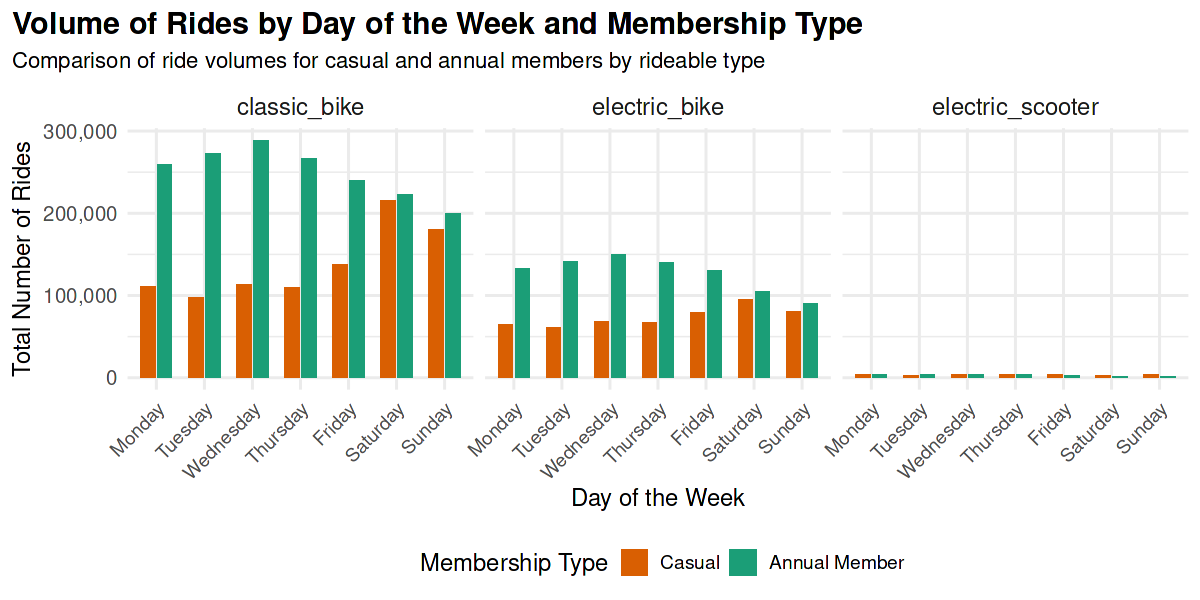

In [24]:
# Calculate total rides by day of the week, rideable type, and membership type 
rides_by_day_type <- cyclistic_24 %>%
  group_by(weekday, rideable_type, member_casual) %>%
  summarise(total_rides = n(), .groups = "drop") %>%
  mutate(
    weekday = factor(weekday, levels = c("Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"),
                     ordered = TRUE)  # Ensure weekdays are ordered from Monday to Sunday
  )

# Plot: Total Rides by Day of the Week, Rideable Type, and Membership Type 
ggplot(rides_by_day_type, aes(x = weekday, y = total_rides, fill = member_casual)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.7), width = 0.6) +  # Stacked bars for casual and annual members
  labs(
    title = "Volume of Rides by Day of the Week and Membership Type",
    subtitle = "Comparison of ride volumes for casual and annual members by rideable type",
    x = "Day of the Week",
    y = "Total Number of Rides",
    fill = "Membership Type"
  ) +
  scale_fill_manual(values = c("casual" = "#d95f02", "member" = "#1b9e77"),  # Custom colors for membership types
                    labels = c("Casual", "Annual Member")) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",  # Move the legend to the bottom
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    axis.text.y = element_text(size = 12),
    strip.text = element_text(size = 14)  # Larger facet labels for rideable types
  ) +
  # Format y-axis labels with commas
  scale_y_continuous(labels = scales::label_comma()) +  # Adds commas to large numbers like 100,000
  facet_wrap(~ rideable_type, scales = "fixed")  # Separate by rideable type (classic_bike, electric_bike, electric_scooter)


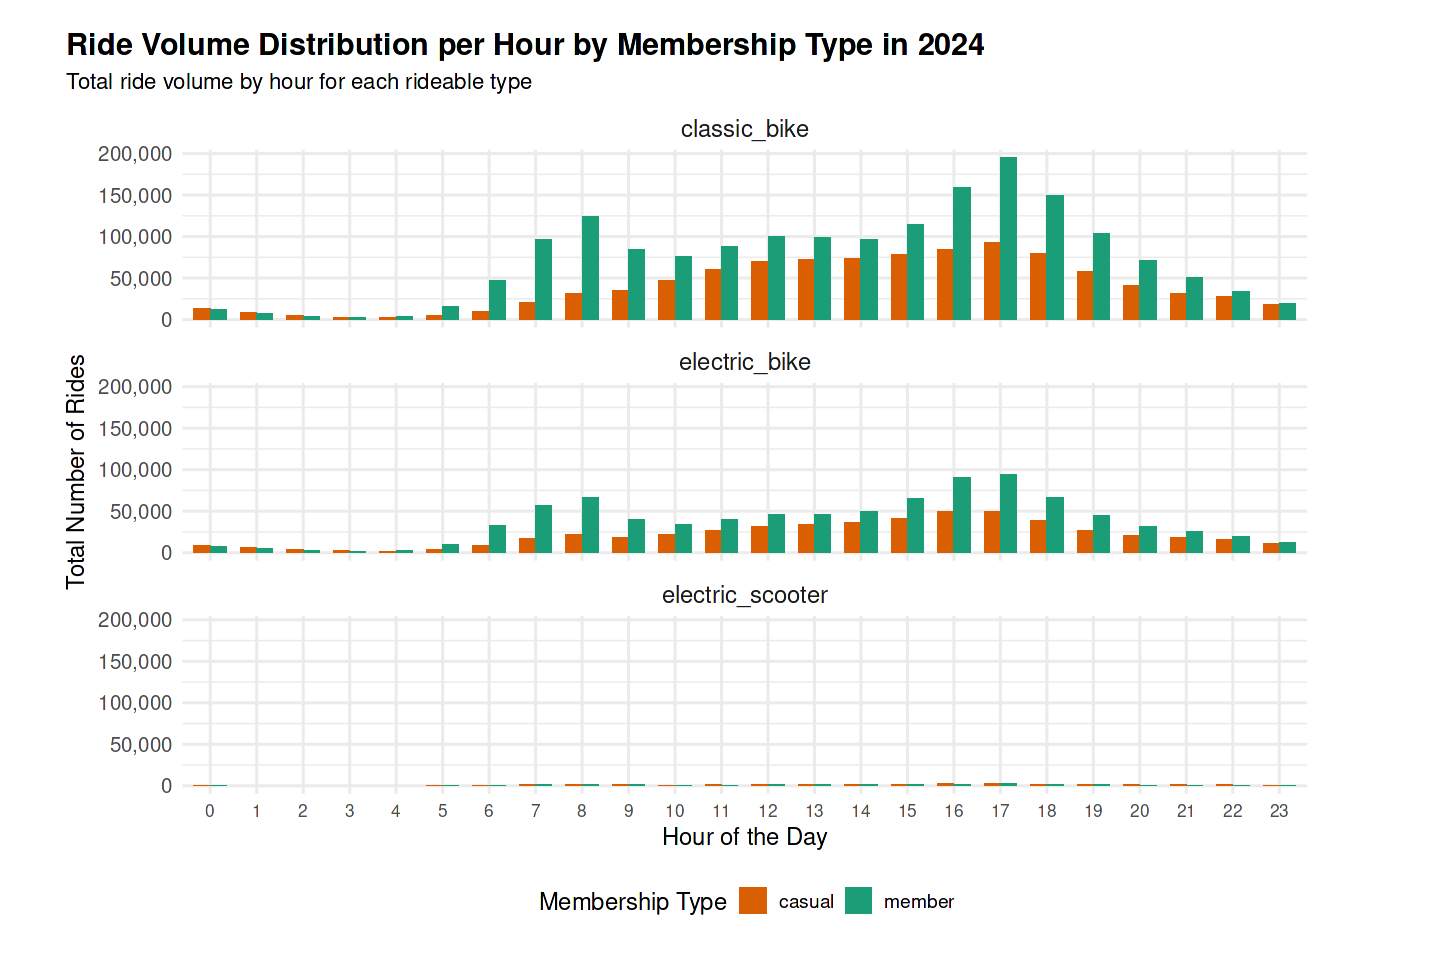

In [25]:
# Increase the plot size for better readability in Kaggle
options(repr.plot.width = 12, repr.plot.height = 8)

# - Calculate total ride volume per hour, rideable type, and membership type -
hourly_ride_distribution <- cyclistic_24 %>%
  mutate(hour = factor(lubridate::hour(started_at), levels = 0:23)) %>%  # Use factor to ensure hours are ordered
  group_by(hour, rideable_type, member_casual) %>%
  summarise(total_rides = n(), .groups = "drop")

# - Plot: Ride Volume Distribution per Hour, Facet Wrap by Rideable Type -
ggplot(hourly_ride_distribution, aes(x = hour, y = total_rides, fill = member_casual)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +  # Side-by-side bars for casual and annual members
  labs(
    title = "Ride Volume Distribution per Hour by Membership Type in 2024",
    subtitle = "Total ride volume by hour for each rideable type",
    x = "Hour of the Day",
    y = "Total Number of Rides",
    fill = "Membership Type"
  ) +
  scale_fill_manual(values = c("casual" = "#d95f02", "member" = "#1b9e77")) +  # Custom colors for membership types
  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",  # Move legend to the bottom
    axis.text.x = element_text(size = 10),  # Rotate x-axis labels for readability
    axis.text.y = element_text(size = 12),
    strip.text = element_text(size = 14),  # Larger facet labels for rideable types
    plot.margin = margin(20, 80, 20, 40)  # Adjust plot margins for better readability
  ) +
  scale_y_continuous(labels = scales::label_comma()) +  # Format the y-axis with commas for readability
  facet_wrap(~ rideable_type, scales = "fixed", ncol = 1)  # Facet by rideable type, 2 columns for better layout


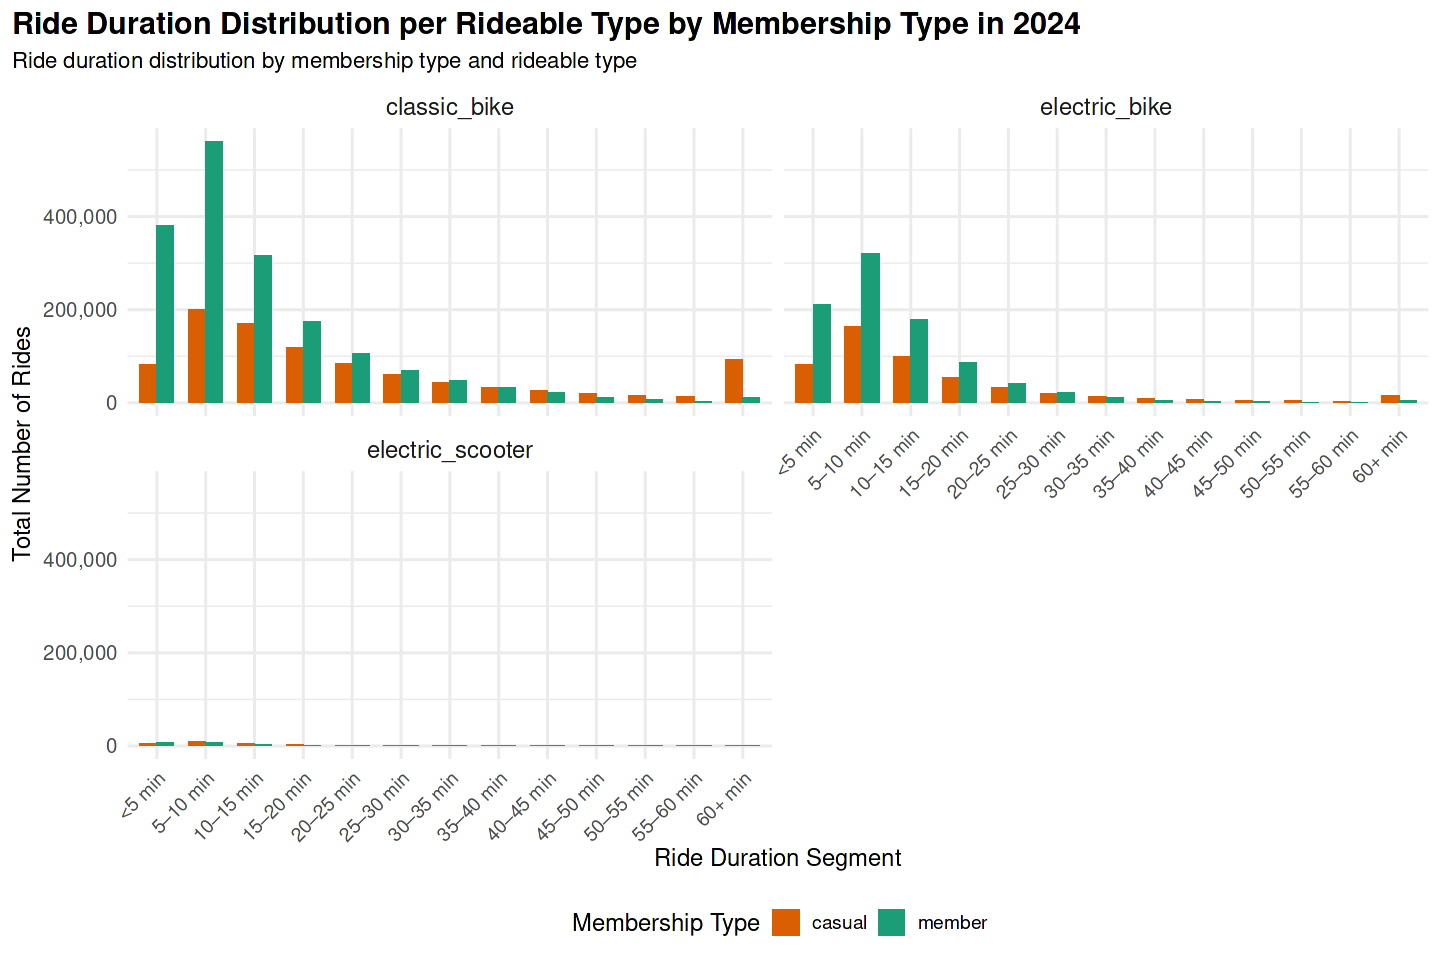

In [26]:
# Create ride duration segments and store in a new data frame
ride_duration_distribution_data <- cyclistic_24 %>%
  mutate(
    duration_segment = case_when(
      ride_length < 5 ~ "<5 min",
      ride_length >= 5 & ride_length < 10 ~ "5–10 min",
      ride_length >= 10 & ride_length < 15 ~ "10–15 min",
      ride_length >= 15 & ride_length < 20 ~ "15–20 min",
      ride_length >= 20 & ride_length < 25 ~ "20–25 min",
      ride_length >= 25 & ride_length < 30 ~ "25–30 min",
      ride_length >= 30 & ride_length < 35 ~ "30–35 min",
      ride_length >= 35 & ride_length < 40 ~ "35–40 min",
      ride_length >= 40 & ride_length < 45 ~ "40–45 min",
      ride_length >= 45 & ride_length < 50 ~ "45–50 min",
      ride_length >= 50 & ride_length < 55 ~ "50–55 min",
      ride_length >= 55 & ride_length < 60 ~ "55–60 min",
      ride_length >= 60 ~ "60+ min"
    )
  ) %>%
  mutate(
    duration_segment = factor(duration_segment, 
                              levels = c("<5 min", "5–10 min", "10–15 min", "15–20 min", 
                                         "20–25 min", "25–30 min", "30–35 min", "35–40 min", 
                                         "40–45 min", "45–50 min", "50–55 min", "55–60 min", "60+ min"), 
                              ordered = TRUE)  # Ensure segments are ordered by duration
  )

# - Calculate total rides per duration segment, rideable type, and membership type -
ride_duration_distribution <- ride_duration_distribution_data %>%
  group_by(duration_segment, rideable_type, member_casual) %>%
  summarise(total_rides = n(), .groups = "drop")

# - Plot: Ride Duration Distribution per Rideable Type by Membership Type -
ggplot(ride_duration_distribution, aes(x = duration_segment, y = total_rides, fill = member_casual)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +  # Side-by-side bars for each membership type
  labs(
    title = "Ride Duration Distribution per Rideable Type by Membership Type in 2024",
    subtitle = "Ride duration distribution by membership type and rideable type",
    x = "Ride Duration Segment",
    y = "Total Number of Rides",
    fill = "Membership Type"
  ) +
  scale_fill_manual(values = c("casual" = "#d95f02", "member" = "#1b9e77")) +  # Custom colors for membership types
  theme_minimal(base_size = 14) +
  theme(
    plot.title.position = "plot",
    plot.title = element_text(face = "bold", size = 18),
    plot.subtitle = element_text(size = 13),
    legend.position = "bottom",  # Move the legend to the bottom
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    axis.text.y = element_text(size = 12),
    strip.text = element_text(size = 14)  # Larger facet labels for rideable types
  ) +
  scale_y_continuous(labels = scales::label_comma()) +  # Use commas to format the y-axis labels
  facet_wrap(~ rideable_type, scales = "fixed", ncol = 2)  # Facet by rideable type with 2 columns


## 5. Share

In this phase, it is expected to share the most relevant findings, key findings, in ways that will enable replying to the following questions:
* What were the similarities found between the casual and annual members?
* What were the differences found between the casual and annual members?


This analysis was presented to Lily Moreno and the Cyclistic Marketing analytics team via a presentation accessible through the following link:

* [Cyclistic 2024 - Presentation.pdf](https://drive.google.com/file/d/1aX45MK_Or6BZPBWUefYXTbCCYplcnoor/view?usp=sharing)

## 6. Act

### Recommendations

1. **Launching marketing campaigns before the Summer-time:**


Considering that ride activity peaks during the summer, the marketing team should begin allocating marketing efforts one to two months before the season starts, when ride volume begins to increase. This timing could make the annual membership appear as a more valuable and timely offer, which could appear as a great moment to engage with promotions.


2. **Offer Higher Ride Allowances on the Weekends to Match Riding Patterns**


Since a considerable number of casual members ride more on weekends than on weekdays, introducing to the plan different ride allowances, with a standard limit during weekdays and a higher one on weekends, could better match riding patterns and increase casual members’ interest in upgrading to an annual plan.


3. **Extend Ride Duration Limits to Encourage Membership Upgrades**


 The longer rides over 60 min represent around 7.3% of the total rides for the casual members, and only 0.6% for the annual members. Increasing the overall duration of the current allowance could support long riders and increase their intention to acquire the annual plan. At the same time, using in-app prompts as “You’ve ridden 6 times during this month, you could have saved x£ with the annual plan” could make the customers understand more about their usage and support their conversion to become annual members.


 To sum up, these recommendations were mainly focused on the differences between casual and annual members; however, it would be essential to convert those casual members who often ride to commute to work, for example, and who are still casual customers, and therefore they should be made aware of the advantages of the annual plan and the benefits considering their usage.

## 7. Conclusion

This project was a way to solidify my learnings throughout the Google Data Analytics Course, and although it was approached as a real business problem, it should not be interpreted as a professional recommendation. There are several considerations and data limitations that were not addressed, as well as potential strategies previously implemented by the organisation, which were unknown and could have influenced the overall outcome. The recommendations presented aim to solve a fictitious business challenge within the context and information provided.

Beyond the analytical results, this project represented a valuable learning experience that allowed me to apply key concepts in R, SQL, and Tableau while following the structured data analysis process, from data cleaning and exploration to visualisation and insight generation. It was both challenging and rewarding to translate raw data into meaningful business insights.

Through this project, I gained a deeper understanding of how data-driven thinking supports decision-making, and I developed a greater appreciation for the importance of clarity, precision, and ethical consideration in analytics. Overall, it was an enriching experience that strengthened my confidence and passion for working with data and solving real-world problems through analytical approaches.